# 05 — Part 2: ResNet50 + Research-Tuned Transformer Decoder
## Same Part-1 CNN, improved Decoder/Training only — Flickr8k + Kaggle T4

This notebook keeps the Part-1 visual encoder **strictly unchanged**:

```text
Image
  ↓
SAME frozen ResNet50 ImageNet-V2
  ↓
7×7×2048
  ↓
49×2048 spatial features
  ↓
Transformer Decoder only
```

The visual backbone, pretrained weights, image preprocessing, data split,
vocabulary, and cached ResNet features are exactly the same as Part 1.

### Decoder-side improvements used in this version

- Standard masked Multi-Head Self-Attention.
- Cross-Attention to the same 49 ResNet spatial tokens.
- **Learned textual positional embeddings**.
- Optional **GloVe-6B 300d initialization** for word embeddings.
- Word embedding projection + residual MLP before the Transformer.
- Standard **Post-LayerNorm** Transformer decoder blocks.
- Linear learning-rate warm-up.
- Smaller batch size for more optimizer updates on Flickr8k.
- Greedy BLEU remains the primary fair comparison.
- Beam-3 BLEU is reported only as a secondary decoding analysis.

No ViT, Swin, CLIP, BLIP, EfficientNet, or visual Transformer encoder is added.


## Why these changes are project-compatible

The project asks to keep the same pretrained image encoder and replace only the
LSTM decoder with a Transformer decoder. The modifications in this notebook are
inside the text-decoder path or optimizer/decoding strategy.

`GloVe` is optional. If a Kaggle input containing `glove.6B.300d.txt` is attached,
the notebook initializes the word embedding table from it. Otherwise it falls
back to a normal trainable embedding and still runs end-to-end.


## Why this architecture matches the project

Among common image-captioning projects, the closest conceptual design is:

**Standard Transformer Decoder trained for captioning**, but with the Part-1
ResNet50 kept as the visual encoder.

We intentionally do **not** use:
- ViT + GPT-2,
- ViT Encoder,
- Swin Transformer,
- CLIP / BLIP / BLIP-2.

Those alternatives change the visual encoder and would make the comparison with
Part 1 less controlled.

### Part-2 deliverables covered in this notebook

- same pretrained Part-1 Image Encoder,
- Transformer Decoder,
- Multi-Head masked Self-Attention,
- Cross-Attention image ↔ caption,
- caption Positional Encoding,
- same Train / Validation / Test data,
- Training and Validation Loss curves,
- BLEU-1 and BLEU-4,
- best checkpoint selected by Validation BLEU-4,
- test image + Ground Truth + generated caption,
- LSTM-vs-Transformer comparison,
- convergence-speed comparison,
- repetition / incomplete-caption analysis,
- simple-vs-complex image discussion support,
- real Cross-Attention maps for important generated words.


## 1. Imports and reproducibility

In [1]:
import os, gc, json, time, math, random, shutil, textwrap
from pathlib import Path
from collections import defaultdict
from contextlib import nullcontext
import hashlib
import ast

import numpy as np
import pandas as pd
import h5py
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
import torchvision.transforms as T

from tqdm.auto import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Configuration

In [2]:
class CFG:
    SEED = 42

    PREP_DIR = None
    BASELINE_DIR = None
    RAW_IMAGES_DIR = None

    # Clean run; do not silently load an older Transformer checkpoint.
    RESUME_FROM_CHECKPOINT = False

    # Transformer
    D_MODEL = 256
    NUM_HEADS = 8
    NUM_LAYERS = 3
    FF_DIM = 768
    DROPOUT = 0.20
    ATTENTION_DROPOUT = 0.10
    FF_DROPOUT = 0.30
    EMBEDDING_DIM = 300
    USE_GLOVE = True
    GLOVE_DIM = 300
    GLOVE_PATH = None
    GLOVE_FINETUNE = True
    GLOVE_LR_SCALE = 0.25
    USE_LEARNED_POSITION = True

    # Training
    BATCH_SIZE = 64
    LR = 1e-4
    WARMUP_FRACTION = 1/15
    WEIGHT_DECAY = 1e-5
    MAX_EPOCHS = 35
    PATIENCE = 8
    # Save the exact maximum validation BLEU-4 checkpoint.
    MIN_DELTA = 0.0
    GRAD_CLIP = 1.0
    # Kaggle/Jupyter + h5py: use single-process loading.
    # This avoids _MultiProcessingDataLoaderIter cleanup errors:
    # 'AssertionError: can only test a child process'.
    # The features are already cached, so NUM_WORKERS=0 is fast enough on a T4.
    NUM_WORKERS = 0
    OPTIMIZER_NAME = "AdamW"

    # Kaggle runtime guard
    TIME_BUDGET_HOURS = 8.0
    TIME_SAFETY_MARGIN_MIN = 15

    # Secondary decoding analysis; primary LSTM comparison stays Greedy.
    RUN_BEAM3_TEST = True
    BEAM_SIZE = 3
    BEAM_LENGTH_PENALTY = 0.7

    # Attention figures
    N_ATTENTION_IMAGES = 4
    MAX_ATTENTION_WORDS_PER_IMAGE = 4

    OUTPUT_DIR = "/kaggle/working/part2_transformer_research_tuned_v5"
    LAST_CKPT = "last_checkpoint.pt"
    BEST_CKPT = "best_checkpoint.pt"
    FINAL_MODEL = "transformer_decoder_final_model.pt"
    FULL_PRESENTATION_MODEL = "transformer_full_presentation_bundle.pt"
    PRESENTATION_SCRIPT = "transformer_presentation_inference.py"


set_seed(CFG.SEED)
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
assert CFG.D_MODEL % CFG.NUM_HEADS == 0
print("Output:", CFG.OUTPUT_DIR)

Output: /kaggle/working/part2_transformer_research_tuned_v5


In [3]:

print("Kaggle/T4 runtime configuration")
print("--------------------------------")
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("VRAM:", f"{props.total_memory / 1024**3:.1f} GB")

print("Batch size:", CFG.BATCH_SIZE)
print("DataLoader workers:", CFG.NUM_WORKERS)
print("AMP enabled:", DEVICE.type == "cuda")

assert CFG.NUM_WORKERS == 0, (
    "For this h5py-backed Kaggle notebook, keep NUM_WORKERS=0 "
    "to avoid Jupyter multiprocessing teardown errors."
)

print("T4-safe DataLoader configuration OK.")


Kaggle/T4 runtime configuration
--------------------------------
Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB
Batch size: 64
DataLoader workers: 0
AMP enabled: True
T4-safe DataLoader configuration OK.


## 3. Locate preprocessing and baseline artifacts

Notebook 01 must provide:
`manifest.json`, `vocab.json`, `captions.csv`, `token_ids.npy`, `features.h5`, `feature_index.json`.

Part 1 is optional for training, but its output is used for the final comparison.

In [4]:

PREP_REQUIRED = {
    "manifest.json",
    "preprocessing_audit.json",
    "vocab.json",
    "captions.csv",
    "token_ids.npy",
    "splits.json",
    "transform_config.json",
    "features.h5",
    "feature_index.json",
}


def has_files(path, required):
    p = Path(path)

    return (
        p.is_dir()
        and required.issubset(
            {
                x.name
                for x in p.iterdir()
                if x.is_file()
            }
        )
    )


def valid_new_preprocessing(path):
    if not has_files(
        path,
        PREP_REQUIRED,
    ):
        return False

    try:
        with open(
            os.path.join(path, "manifest.json"),
            "r",
            encoding="utf-8",
        ) as f:
            candidate_manifest = json.load(f)

        with open(
            os.path.join(path, "preprocessing_audit.json"),
            "r",
            encoding="utf-8",
        ) as f:
            candidate_audit = json.load(f)

        return (
            candidate_manifest.get("artifact_version") == 1
            and candidate_manifest.get("dataset") == "Flickr8k"
            and int(candidate_audit.get("final_unique_images", 0)) > 7000
            and int(candidate_audit.get("final_caption_rows", 0)) > 30000
        )

    except Exception:
        return False


def find_preprocessing_dir():
    if CFG.PREP_DIR is not None:
        assert valid_new_preprocessing(
            CFG.PREP_DIR
        ), (
            "CFG.PREP_DIR is not the NEW preprocessing output."
        )

        return str(
            CFG.PREP_DIR
        )

    candidates = []

    for root in [
        "/kaggle/working",
        "/kaggle/input",
    ]:
        if not os.path.exists(root):
            continue

        for dirpath, _, files in os.walk(root):
            if not PREP_REQUIRED.issubset(
                set(files)
            ):
                continue

            if not valid_new_preprocessing(
                dirpath
            ):
                continue

            with open(
                os.path.join(
                    dirpath,
                    "preprocessing_audit.json",
                ),
                "r",
                encoding="utf-8",
            ) as f:
                audit = json.load(f)

            candidates.append(
                (
                    int(
                        audit[
                            "final_unique_images"
                        ]
                    ),
                    int(
                        audit[
                            "final_caption_rows"
                        ]
                    ),
                    dirpath,
                )
            )

    if not candidates:
        return None

    candidates.sort(
        reverse=True
    )

    return candidates[0][2]


PREP_DIR = find_preprocessing_dir()

assert PREP_DIR is not None, (
    "Run/attach the NEW Notebook-01 preprocessing output first."
)

print(
    "NEW preprocessing:",
    PREP_DIR,
)


NEW preprocessing: /kaggle/input/datasets/amirmrt04/dl-dataset/preprocessed


## 4. Load metadata, vocabulary, token IDs, and feature information

In [5]:
# Required for the preprocessing SHA-256 fingerprint.
import hashlib
assert hasattr(hashlib, 'sha256')
print("hashlib ready.")

hashlib ready.


In [6]:

with open(
    os.path.join(
        PREP_DIR,
        "manifest.json",
    ),
    "r",
    encoding="utf-8",
) as f:
    manifest = json.load(f)

with open(
    os.path.join(
        PREP_DIR,
        "preprocessing_audit.json",
    ),
    "r",
    encoding="utf-8",
) as f:
    preprocessing_audit = json.load(f)

with open(
    os.path.join(
        PREP_DIR,
        "vocab.json",
    ),
    "r",
    encoding="utf-8",
) as f:
    vocab = json.load(f)

with open(
    os.path.join(
        PREP_DIR,
        "feature_index.json",
    ),
    "r",
    encoding="utf-8",
) as f:
    feature_index = json.load(f)

captions_df = pd.read_csv(
    os.path.join(
        PREP_DIR,
        "captions.csv",
    )
)

TOKEN_IDS_PATH = os.path.join(
    PREP_DIR,
    "token_ids.npy",
)

FEATURES_H5_PATH = os.path.join(
    PREP_DIR,
    "features.h5",
)

token_ids_mmap = np.load(
    TOKEN_IDS_PATH,
    mmap_mode="r",
)

word2idx = vocab["word2idx"]
idx2word = vocab["idx2word"]

PAD_ID = int(
    vocab["special_tokens"]["pad_id"]
)
START_ID = int(
    vocab["special_tokens"]["start_id"]
)
END_ID = int(
    vocab["special_tokens"]["end_id"]
)
UNK_ID = int(
    vocab["special_tokens"]["unk_id"]
)

VOCAB_SIZE = len(
    idx2word
)

MAX_LEN = int(
    manifest["text"]["max_len"]
)

FEAT_DIM = int(
    feature_index["feature_dim"]
)

NUM_IMAGE_TOKENS = int(
    feature_index["num_tokens"]
)

GEN_MAX_NEW_TOKENS = (
    MAX_LEN - 1
)


def preprocessing_fingerprint(prep_dir):
    sha = hashlib.sha256()

    for filename in [
        "manifest.json",
        "vocab.json",
        "splits.json",
        "feature_index.json",
    ]:
        with open(
            os.path.join(
                prep_dir,
                filename,
            ),
            "rb",
        ) as f:
            sha.update(
                filename.encode(
                    "utf-8"
                )
            )
            sha.update(
                f.read()
            )

    return sha.hexdigest()


PREPROCESSING_FINGERPRINT = (
    preprocessing_fingerprint(
        PREP_DIR
    )
)

# ------------------------------------------------------------
# Strong preprocessing compatibility checks
# ------------------------------------------------------------
assert manifest[
    "artifact_version"
] == 1

assert manifest[
    "dataset"
] == "Flickr8k"

assert manifest[
    "text"
][
    "vocabulary_built_from"
] == "train"

assert manifest[
    "text"
][
    "max_len_built_from"
] == "train"

assert len(
    captions_df
) == token_ids_mmap.shape[
    0
]

assert (
    token_ids_mmap.shape[
        1
    ]
    == MAX_LEN
)

assert int(
    manifest["counts"]["captions"]
) == len(
    captions_df
)

assert int(
    manifest["counts"]["unique_images"]
) == captions_df[
    "image"
].nunique()

assert int(
    preprocessing_audit[
        "final_caption_rows"
    ]
) == len(
    captions_df
)

assert int(
    preprocessing_audit[
        "final_unique_images"
    ]
) == captions_df[
    "image"
].nunique()

assert int(
    manifest["text"]["vocab_size"]
) == VOCAB_SIZE

assert VOCAB_SIZE == len(
    word2idx
)

assert NUM_IMAGE_TOKENS == 49, (
    "Transformer Cross-Attention and attention maps require 7×7 = 49 spatial tokens."
)

assert FEAT_DIM == 2048

assert captions_df[
    "feature_idx"
].notna().all()

print(
    "Dataset:",
    manifest["dataset"],
)

print(
    "Vocabulary:",
    VOCAB_SIZE,
)

print(
    "MAX_LEN:",
    MAX_LEN,
)

print(
    "Image memory:",
    (
        NUM_IMAGE_TOKENS,
        FEAT_DIM,
    ),
)

print(
    "Preprocessing fingerprint:",
    PREPROCESSING_FINGERPRINT,
)

display(
    captions_df.groupby(
        "split"
    ).agg(
        captions=(
            "image",
            "size",
        ),
        images=(
            "image",
            "nunique",
        ),
    )
)


# ------------------------------------------------------------
# Find ONLY a Part-1 baseline built from this exact preprocessing.
# ------------------------------------------------------------
BASELINE_REQUIRED = {
    "part1_manifest.json",
    "test_metrics.json",
    "training_history.csv",
    "error_analysis.csv",
}


def matching_baseline_dir(path):
    if not has_files(
        path,
        BASELINE_REQUIRED,
    ):
        return False

    try:
        with open(
            os.path.join(
                path,
                "part1_manifest.json",
            ),
            "r",
            encoding="utf-8",
        ) as f:
            part1_manifest = json.load(
                f
            )

        return (
            part1_manifest.get(
                "preprocessing_fingerprint"
            )
            == PREPROCESSING_FINGERPRINT
        )

    except Exception:
        return False


def find_matching_baseline():
    if CFG.BASELINE_DIR is not None:
        assert matching_baseline_dir(
            CFG.BASELINE_DIR
        ), (
            "CFG.BASELINE_DIR exists but was not trained "
            "from this exact preprocessing dataset."
        )

        return str(
            CFG.BASELINE_DIR
        )

    matches = []

    for root in [
        "/kaggle/working",
        "/kaggle/input",
    ]:
        if not os.path.exists(
            root
        ):
            continue

        for dirpath, _, files in os.walk(
            root
        ):
            if not BASELINE_REQUIRED.issubset(
                set(files)
            ):
                continue

            if matching_baseline_dir(
                dirpath
            ):
                matches.append(
                    dirpath
                )

    if not matches:
        return None

    # Prefer the clean-v2-named output when present.
    matches.sort(
        key=lambda p: (
            "v2" in p.lower(),
            p,
        ),
        reverse=True,
    )

    return matches[0]


BASELINE_DIR = (
    find_matching_baseline()
)

print(
    "\nMatching Part-1 baseline:",
    (
        BASELINE_DIR
        if BASELINE_DIR
        else (
            "not found — attach the NEW Part-1 output "
            "before the final comparison run"
        )
    ),
)

print(
    "\nNEW PREPROCESSING COMPATIBILITY CHECKS PASSED."
)


Dataset: Flickr8k
Vocabulary: 2659
MAX_LEN: 20
Image memory: (49, 2048)
Preprocessing fingerprint: 9076e5061367af04b11a8549a08d3a5ea65b5c89c0b41cf8c4838ecf4f409df7


,captions,images
split,,
test,4050,810
train,32360,6472
val,4045,809



Matching Part-1 baseline: /kaggle/input/datasets/amirmrt04/cnn-lstm-output/part1_baseline_v2/presentation_package

NEW PREPROCESSING COMPATIBILITY CHECKS PASSED.


## Encoder invariance check — CNN must remain unchanged

This cell proves that Part 2 uses the same visual encoder specification as Part 1.

The cached tensor `(49, 2048)` comes from the last convolutional feature map of
the same frozen ResNet50. Part 1 used `mean(axis=0)` only to create the global
vector expected by LSTM. Here we intentionally retain the 49 regions for
Cross-Attention.


In [7]:
assert manifest["image_transform"]["encoder"] == "resnet50"
assert manifest["image_transform"]["weights"] == "IMAGENET1K_V2"

assert feature_index["encoder"] == "resnet50"
assert feature_index["weights"] == "IMAGENET1K_V2"
assert feature_index["mode"] == "spatial"
assert NUM_IMAGE_TOKENS == 49
assert FEAT_DIM == 2048

print("CNN ENCODER INVARIANCE CHECK")
print("----------------------------")
print("Encoder network : ResNet50")
print("Weights         : ImageNet-V2")
print("Trainable CNN   : No — frozen/precomputed")
print("Feature map     : 7×7×2048")
print("Transformer mem.: 49×2048")
print()
print(
    "Part 1: same 49 ResNet features -> mean pooling -> LSTM.\\n"
    "Part 2: same 49 ResNet features -> Cross-Attention -> Transformer.\\n"
    "CNN backbone and its weights are unchanged."
)

if BASELINE_DIR is not None:
    with open(
        os.path.join(BASELINE_DIR, "part1_manifest.json"),
        "r",
        encoding="utf-8",
    ) as f:
        _part1_manifest_check = json.load(f)

    assert (
        _part1_manifest_check["preprocessing_fingerprint"]
        == PREPROCESSING_FINGERPRINT
    )

    print("\\nMatching Part-1 fingerprint confirmed.")
else:
    print(
        "\\nPart-1 output is not attached yet; "
        "training can run, but final comparison cells will be partial."
    )

CNN ENCODER INVARIANCE CHECK
----------------------------
Encoder network : ResNet50
Weights         : ImageNet-V2
Trainable CNN   : No — frozen/precomputed
Feature map     : 7×7×2048
Transformer mem.: 49×2048

Part 1: same 49 ResNet features -> mean pooling -> LSTM.\nPart 2: same 49 ResNet features -> Cross-Attention -> Transformer.\nCNN backbone and its weights are unchanged.
\nMatching Part-1 fingerprint confirmed.


## Optional pretrained GloVe initialization

A small caption dataset has limited linguistic supervision. This cell can
initialize the **decoder word embeddings only** from GloVe.

For the GloVe-enabled run, attach a Kaggle dataset containing:

```text
glove.6B.300d.txt
```

No GloVe file is needed at inference time because the learned embedding weights
are stored in the Transformer checkpoint.


In [8]:

def discover_glove_file():
    if CFG.GLOVE_PATH is not None:
        assert os.path.isfile(CFG.GLOVE_PATH)
        return CFG.GLOVE_PATH

    if not CFG.USE_GLOVE:
        return None

    candidates = []

    for root in ["/kaggle/input"]:
        if not os.path.exists(root):
            continue

        for dirpath, _, files in os.walk(root):
            for filename in files:
                low = filename.lower()

                if (
                    low == "glove.6b.300d.txt"
                    or (
                        "glove" in low
                        and "300d" in low
                        and low.endswith(".txt")
                    )
                ):
                    path = os.path.join(
                        dirpath,
                        filename,
                    )

                    candidates.append(
                        path
                    )

    if not candidates:
        return None

    candidates.sort(
        key=lambda p: (
            os.path.basename(p).lower()
            != "glove.6b.300d.txt",
            len(p),
        )
    )

    return candidates[0]


GLOVE_FILE = discover_glove_file()

if CFG.USE_GLOVE and GLOVE_FILE is None:
    print(
        "WARNING: GloVe 300d was requested but no file was found. "
        "The model will use trainable random word embeddings instead."
    )
else:
    print(
        "GloVe file:",
        GLOVE_FILE,
    )


def build_embedding_matrix(
    glove_file,
    word2idx,
    embedding_dim,
):
    """
    Stream the GloVe text file and load only words used by this project.
    This avoids keeping all 400k vectors in RAM.
    """
    rng = np.random.default_rng(
        CFG.SEED
    )

    matrix = rng.normal(
        loc=0.0,
        scale=0.02,
        size=(
            len(word2idx),
            embedding_dim,
        ),
    ).astype(
        np.float32
    )

    matrix[PAD_ID] = 0.0

    if glove_file is None:
        return (
            matrix,
            0,
        )

    wanted = {
        word
        for word in word2idx
        if not word.startswith("<")
    }

    found = 0

    with open(
        glove_file,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as f:
        for line in tqdm(
            f,
            desc="Loading required GloVe vectors",
        ):
            pieces = line.rstrip().split(" ")

            if len(pieces) != embedding_dim + 1:
                continue

            word = pieces[0]

            if word not in wanted:
                continue

            idx = word2idx.get(
                word
            )

            if idx is None:
                continue

            try:
                vector = np.asarray(
                    pieces[1:],
                    dtype=np.float32,
                )
            except ValueError:
                continue

            matrix[idx] = vector
            found += 1

            if found >= len(wanted):
                break

    return (
        matrix,
        found,
    )


PRETRAINED_EMBEDDING_MATRIX, GLOVE_WORDS_FOUND = build_embedding_matrix(
    GLOVE_FILE,
    word2idx,
    CFG.EMBEDDING_DIM,
)

regular_vocab_words = max(
    1,
    VOCAB_SIZE - 4,
)

GLOVE_COVERAGE = (
    GLOVE_WORDS_FOUND
    / regular_vocab_words
)

print(
    f"GloVe coverage: "
    f"{GLOVE_WORDS_FOUND}/{regular_vocab_words} "
    f"({100 * GLOVE_COVERAGE:.2f}%)"
)


GloVe coverage: 0/2655 (0.00%)


## 5. Dataset and DataLoader

For Part 2 we **do not mean-pool** the visual features. Every sample keeps all 49 spatial tokens so that Cross-Attention can focus on different image regions.

In [9]:
class TransformerCaptionDataset(Dataset):
    def __init__(self, df, token_path, h5_path, split):
        sdf = df[df["split"] == split].reset_index()
        self.original_indices = sdf["index"].to_numpy(np.int64)
        self.feature_indices = sdf["feature_idx"].to_numpy(np.int64)
        self.token_path = token_path
        self.h5_path = h5_path
        self._tokens = None
        self._h5 = None

    def __len__(self):
        return len(self.original_indices)

    def _get_tokens(self):
        if self._tokens is None:
            self._tokens = np.load(self.token_path, mmap_mode="r")
        return self._tokens

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, "r")
        return self._h5

    def __getitem__(self, idx):
        h5 = self._get_h5()
        tokens = self._get_tokens()

        spatial = np.asarray(
            h5["features"][int(self.feature_indices[idx])],
            dtype=np.float32,
        )
        caption = np.asarray(tokens[self.original_indices[idx]], dtype=np.int64)

        return torch.from_numpy(spatial), torch.from_numpy(caption)

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_tokens"] = None
        state["_h5"] = None
        return state


def make_loader(split, shuffle):
    ds = TransformerCaptionDataset(
        captions_df, TOKEN_IDS_PATH, FEATURES_H5_PATH, split
    )
    g = torch.Generator().manual_seed(CFG.SEED)
    loader = DataLoader(
        ds,
        batch_size=CFG.BATCH_SIZE,
        shuffle=shuffle,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        # IMPORTANT for Kaggle/Jupyter + h5py:
        # keep data loading in the notebook process. The feature cache is
        # already precomputed, so multiprocessing gives little benefit here
        # and can trigger DataLoader child-process teardown errors.
        persistent_workers=False,
        generator=g if shuffle else None,
    )
    return ds, loader


train_ds, train_loader = make_loader("train", True)
val_ds, val_loader = make_loader("val", False)
test_ds, test_loader = make_loader("test", False)

print(len(train_ds), len(val_ds), len(test_ds))
with h5py.File(FEATURES_H5_PATH, "r") as h5:
    print("features.h5:", h5["features"].shape)

32360 4045 4050
features.h5: (8091, 49, 2048)


## 6. Sinusoidal Positional Encoding

Self-attention has no inherent word-order information. We therefore add sinusoidal positional encoding to each caption token embedding:

\[
PE(pos,2i)=\sin(pos/10000^{2i/d_{model}})
\]

\[
PE(pos,2i+1)=\cos(pos/10000^{2i/d_{model}})
\]

In [10]:

class LearnedTokenPositionEmbedding(nn.Module):
    """
    Token embedding + learned textual positional embedding.

    This is still Positional Encoding as required by the project,
    but positions are learned from Flickr8k instead of being sinusoidal.
    """

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        d_model,
        max_len,
        pad_id,
        dropout,
        pretrained_matrix=None,
        finetune_pretrained=True,
    ):
        super().__init__()

        self.pad_id = int(
            pad_id
        )

        self.embedding_dim = int(
            embedding_dim
        )

        self.d_model = int(
            d_model
        )

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_id,
        )

        if pretrained_matrix is not None:
            weights = torch.as_tensor(
                pretrained_matrix,
                dtype=torch.float32,
            )

            assert tuple(
                weights.shape
            ) == (
                vocab_size,
                embedding_dim,
            )

            with torch.no_grad():
                self.token_embedding.weight.copy_(
                    weights
                )

            self.token_embedding.weight.requires_grad = bool(
                finetune_pretrained
            )

        self.word_projection = nn.Linear(
            embedding_dim,
            d_model,
        )

        self.word_residual = nn.Sequential(
            nn.Linear(
                d_model,
                d_model,
            ),
            nn.LeakyReLU(
                negative_slope=0.1,
            ),
            nn.Linear(
                d_model,
                d_model,
            ),
        )

        self.position_embedding = nn.Embedding(
            max_len,
            d_model,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.activation = nn.LeakyReLU(
            negative_slope=0.1
        )

    def forward(
        self,
        token_ids,
    ):
        batch_size, seq_len = token_ids.shape

        word = self.token_embedding(
            token_ids
        )

        word = self.activation(
            self.word_projection(
                word
            )
        )

        word = self.activation(
            word
            + self.word_residual(
                word
            )
        )

        positions = torch.arange(
            seq_len,
            dtype=torch.long,
            device=token_ids.device,
        )

        pos = self.position_embedding(
            positions
        ).unsqueeze(
            0
        )

        return self.dropout(
            word + pos
        )


## 7. Custom Transformer Decoder Layer

A custom decoder layer is used so that Cross-Attention weights are directly accessible for visualization.

Each layer contains:

1. Masked Multi-Head Self-Attention
2. Multi-Head Cross-Attention
3. Feed-Forward Network
4. Residual connections
5. Layer Normalization
6. Dropout

In [11]:

class TransformerCaptionDecoderLayer(nn.Module):
    """
    Standard Transformer decoder block using Post-LayerNorm:
      masked self-attention -> cross-attention -> FFN.
    """

    def __init__(
        self,
        d_model,
        num_heads,
        ff_dim,
        dropout,
        attention_dropout,
        ff_dropout,
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            d_model,
            num_heads,
            dropout=attention_dropout,
            batch_first=True,
        )

        self.cross_attn = nn.MultiheadAttention(
            d_model,
            num_heads,
            dropout=attention_dropout,
            batch_first=True,
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                d_model,
                ff_dim,
            ),
            nn.ReLU(),
            nn.Dropout(
                ff_dropout
            ),
            nn.Linear(
                ff_dim,
                d_model,
            ),
        )

        self.norm1 = nn.LayerNorm(
            d_model
        )

        self.norm2 = nn.LayerNorm(
            d_model
        )

        self.norm3 = nn.LayerNorm(
            d_model
        )

        self.drop1 = nn.Dropout(
            dropout
        )

        self.drop2 = nn.Dropout(
            dropout
        )

        self.drop3 = nn.Dropout(
            dropout
        )

    def forward(
        self,
        x,
        memory,
        causal_mask,
        tgt_key_padding_mask=None,
        return_cross_attention=False,
    ):
        self_out, _ = self.self_attn(
            x,
            x,
            x,
            attn_mask=causal_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False,
        )

        x = self.norm1(
            x
            + self.drop1(
                self_out
            )
        )

        cross_out, cross_weights = self.cross_attn(
            x,
            memory,
            memory,
            need_weights=return_cross_attention,
            average_attn_weights=False,
        )

        x = self.norm2(
            x
            + self.drop2(
                cross_out
            )
        )

        ff_out = self.ffn(
            x
        )

        x = self.norm3(
            x
            + self.drop3(
                ff_out
            )
        )

        return (
            x,
            cross_weights,
        )


## 8. Complete Transformer Image Caption Model

### Image memory
`(B, 49, 2048) → Linear → (B, 49, d_model)`

### Text
`Token IDs → Embedding × √d_model → Positional Encoding`

### Causal mask
At position *t*, Self-Attention can only see positions `≤ t`; future words are blocked.

### Cross-Attention
Caption representations are the queries; the 49 projected ResNet spatial tokens are keys/values.

In [12]:

class TransformerCaptionModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        feat_dim,
        embedding_dim,
        d_model,
        num_heads,
        num_layers,
        ff_dim,
        dropout,
        attention_dropout,
        ff_dropout,
        max_len,
        pad_id,
        pretrained_embedding_matrix=None,
        finetune_pretrained=True,
    ):
        super().__init__()

        self.d_model = int(
            d_model
        )

        self.pad_id = int(
            pad_id
        )

        # Same ResNet50 features; this is only a dimensional adapter.
        self.image_projection = nn.Linear(
            feat_dim,
            d_model,
        )

        self.image_activation = nn.LeakyReLU(
            negative_slope=0.1
        )

        self.text_embedding = LearnedTokenPositionEmbedding(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            d_model=d_model,
            max_len=max_len,
            pad_id=pad_id,
            dropout=dropout,
            pretrained_matrix=pretrained_embedding_matrix,
            finetune_pretrained=finetune_pretrained,
        )

        self.layers = nn.ModuleList(
            [
                TransformerCaptionDecoderLayer(
                    d_model=d_model,
                    num_heads=num_heads,
                    ff_dim=ff_dim,
                    dropout=dropout,
                    attention_dropout=attention_dropout,
                    ff_dropout=ff_dropout,
                )
                for _ in range(
                    num_layers
                )
            ]
        )

        self.output_dropout = nn.Dropout(
            dropout
        )

        self.output_projection = nn.Linear(
            d_model,
            vocab_size,
        )

    @staticmethod
    def causal_mask(
        seq_len,
        device,
    ):
        return torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                dtype=torch.bool,
                device=device,
            ),
            diagonal=1,
        )

    def encode_image(
        self,
        spatial_features,
    ):
        assert spatial_features.ndim == 3
        assert spatial_features.shape[1] == NUM_IMAGE_TOKENS
        assert spatial_features.shape[2] == FEAT_DIM

        return self.image_activation(
            self.image_projection(
                spatial_features
            )
        )

    def forward(
        self,
        spatial_features,
        input_tokens,
        return_cross_attention=False,
    ):
        memory = self.encode_image(
            spatial_features
        )

        x = self.text_embedding(
            input_tokens
        )

        mask = self.causal_mask(
            input_tokens.size(1),
            input_tokens.device,
        )

        padding_mask = input_tokens.eq(
            self.pad_id
        )

        attentions = []

        for layer in self.layers:
            x, cross_attn = layer(
                x,
                memory,
                causal_mask=mask,
                tgt_key_padding_mask=padding_mask,
                return_cross_attention=return_cross_attention,
            )

            if return_cross_attention:
                attentions.append(
                    cross_attn
                )

        logits = self.output_projection(
            self.output_dropout(
                x
            )
        )

        if return_cross_attention:
            return (
                logits,
                attentions,
            )

        return logits

    @torch.no_grad()
    def generate(
        self,
        spatial_features,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
        return_attention=False,
    ):
        self.eval()

        batch_size = spatial_features.size(
            0
        )

        generated = torch.full(
            (
                batch_size,
                max_new_tokens,
            ),
            pad_id,
            dtype=torch.long,
            device=spatial_features.device,
        )

        prefix = torch.full(
            (
                batch_size,
                1,
            ),
            start_id,
            dtype=torch.long,
            device=spatial_features.device,
        )

        finished = torch.zeros(
            batch_size,
            dtype=torch.bool,
            device=spatial_features.device,
        )

        attention_history = []

        for step in range(
            max_new_tokens
        ):
            if return_attention:
                logits, cross_attn = self(
                    spatial_features,
                    prefix,
                    return_cross_attention=True,
                )

                current = (
                    cross_attn[-1][
                        :,
                        :,
                        -1,
                        :,
                    ]
                    .mean(
                        dim=1
                    )
                )

                attention_history.append(
                    current.detach()
                )

            else:
                logits = self(
                    spatial_features,
                    prefix,
                )

            next_logits = logits[
                :,
                -1,
                :,
            ].clone()

            next_logits[
                :,
                pad_id,
            ] = -torch.inf

            next_logits[
                :,
                start_id,
            ] = -torch.inf

            next_token = next_logits.argmax(
                dim=-1
            )

            next_token = torch.where(
                finished,
                torch.full_like(
                    next_token,
                    pad_id,
                ),
                next_token,
            )

            generated[
                :,
                step,
            ] = next_token

            just_finished = next_token.eq(
                end_id
            )

            finished = (
                finished
                | just_finished
            )

            prefix_token = torch.where(
                finished,
                torch.full_like(
                    next_token,
                    end_id,
                ),
                next_token,
            )

            prefix = torch.cat(
                [
                    prefix,
                    prefix_token.unsqueeze(
                        1
                    ),
                ],
                dim=1,
            )

            if finished.all():
                break

        return (
            generated,
            finished,
            attention_history,
        )


## 9. Instantiate model and run structural sanity checks

In [13]:

model = TransformerCaptionModel(
    vocab_size=VOCAB_SIZE,
    feat_dim=FEAT_DIM,
    embedding_dim=CFG.EMBEDDING_DIM,
    d_model=CFG.D_MODEL,
    num_heads=CFG.NUM_HEADS,
    num_layers=CFG.NUM_LAYERS,
    ff_dim=CFG.FF_DIM,
    dropout=CFG.DROPOUT,
    attention_dropout=CFG.ATTENTION_DROPOUT,
    ff_dropout=CFG.FF_DROPOUT,
    max_len=MAX_LEN,
    pad_id=PAD_ID,
    pretrained_embedding_matrix=PRETRAINED_EMBEDDING_MATRIX,
    finetune_pretrained=CFG.GLOVE_FINETUNE,
).to(DEVICE)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)
print(
    f"\nTotal parameters: {total_params:,}"
)
print(
    f"Trainable parameters: {trainable_params:,}"
)
print(
    f"Approx model size FP32: {total_params * 4 / 1e6:.1f} MB"
)

dummy_image = torch.randn(
    2,
    NUM_IMAGE_TOKENS,
    FEAT_DIM,
    device=DEVICE,
)

dummy_text = torch.tensor(
    [
        [
            START_ID,
            4,
            5,
            PAD_ID,
        ],
        [
            START_ID,
            7,
            8,
            9,
        ],
    ],
    dtype=torch.long,
    device=DEVICE,
)

with torch.no_grad():
    dummy_logits, dummy_attn = model(
        dummy_image,
        dummy_text,
        return_cross_attention=True,
    )

print(
    "Logits:",
    tuple(
        dummy_logits.shape
    ),
)

print(
    "Cross-attention:",
    tuple(
        dummy_attn[-1].shape
    ),
)

assert dummy_logits.shape == (
    2,
    4,
    VOCAB_SIZE,
)

assert dummy_attn[-1].shape == (
    2,
    CFG.NUM_HEADS,
    4,
    NUM_IMAGE_TOKENS,
)

test_mask = model.causal_mask(
    4,
    DEVICE,
)

assert (
    test_mask[
        0,
        1,
    ]
    and not test_mask[
        1,
        0,
    ]
)

del (
    dummy_image,
    dummy_text,
    dummy_logits,
    dummy_attn,
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


TransformerCaptionModel(
  (image_projection): Linear(in_features=2048, out_features=256, bias=True)
  (image_activation): LeakyReLU(negative_slope=0.1)
  (text_embedding): LearnedTokenPositionEmbedding(
    (token_embedding): Embedding(2659, 300, padding_idx=0)
    (word_projection): Linear(in_features=300, out_features=256, bias=True)
    (word_residual): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.1)
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
    (position_embedding): Embedding(20, 256)
    (dropout): Dropout(p=0.2, inplace=False)
    (activation): LeakyReLU(negative_slope=0.1)
  )
  (layers): ModuleList(
    (0-2): 3 x TransformerCaptionDecoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (cross_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_

## 10. Loss and optimizer

Teacher forcing:

```text
Input : <start> a man rides ...
Target:         a man rides ... <end>
```

Padding positions are ignored by Cross-Entropy Loss.

In [14]:

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

# Separate embedding LR when GloVe initialization is being fine-tuned.
embedding_params = list(
    model.text_embedding.token_embedding.parameters()
)

embedding_param_ids = {
    id(p)
    for p in embedding_params
}

other_params = [
    p
    for p in model.parameters()
    if (
        p.requires_grad
        and id(p)
        not in embedding_param_ids
    )
]

param_groups = [
    {
        "params": other_params,
        "lr": CFG.LR,
    },
]

if any(
    p.requires_grad
    for p in embedding_params
):
    param_groups.append(
        {
            "params": embedding_params,
            "lr": (
                CFG.LR
                * CFG.GLOVE_LR_SCALE
                if GLOVE_FILE is not None
                else CFG.LR
            ),
        }
    )

optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay=CFG.WEIGHT_DECAY,
)

# Keras-style linear warm-up, then hold the target LR constant.
TOTAL_OPTIMIZER_STEPS = (
    len(train_loader)
    * CFG.MAX_EPOCHS
)

WARMUP_STEPS = max(
    1,
    int(
        TOTAL_OPTIMIZER_STEPS
        * CFG.WARMUP_FRACTION
    ),
)


def warmup_lambda(
    step,
):
    if step < WARMUP_STEPS:
        return float(
            step + 1
        ) / float(
            WARMUP_STEPS
        )

    return 1.0


lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=warmup_lambda,
)

AMP_ENABLED = (
    DEVICE.type == "cuda"
)

try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP_ENABLED,
    )

    def amp_context():
        return (
            torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
            )
            if AMP_ENABLED
            else nullcontext()
        )

except (
    AttributeError,
    TypeError,
):
    scaler = torch.cuda.amp.GradScaler(
        enabled=AMP_ENABLED
    )

    def amp_context():
        return (
            torch.cuda.amp.autocast()
            if AMP_ENABLED
            else nullcontext()
        )


LAST_CKPT_PATH = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.LAST_CKPT,
)

BEST_CKPT_PATH = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.BEST_CKPT,
)


def model_config():
    return {
        "vocab_size": VOCAB_SIZE,
        "feat_dim": FEAT_DIM,
        "embedding_dim": CFG.EMBEDDING_DIM,
        "d_model": CFG.D_MODEL,
        "num_heads": CFG.NUM_HEADS,
        "num_layers": CFG.NUM_LAYERS,
        "ff_dim": CFG.FF_DIM,
        "dropout": CFG.DROPOUT,
        "attention_dropout": CFG.ATTENTION_DROPOUT,
        "ff_dropout": CFG.FF_DROPOUT,
        "max_len": MAX_LEN,
        "pad_id": PAD_ID,
        "learned_text_position": True,
        "word_residual_mapping": True,
        "glove_initialized": bool(
            GLOVE_FILE is not None
        ),
        "glove_dimension": CFG.GLOVE_DIM,
        "glove_coverage": float(
            GLOVE_COVERAGE
        ),
    }


## 11. Resume-safe checkpoint utilities

In [15]:

def save_checkpoint(
    path,
    epoch,
    best_bleu4,
    patience_count,
    history,
):
    torch.save(
        {
            "format_version": 5,
            "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
            "epoch": int(
                epoch
            ),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": lr_scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_bleu4": float(
                best_bleu4
            ),
            "epochs_without_improvement": int(
                patience_count
            ),
            "history": history,
            "model_config": model_config(),
        },
        path,
    )


def load_training_checkpoint(
    path,
):
    ckpt = torch.load(
        path,
        map_location=DEVICE,
    )

    assert ckpt.get(
        "preprocessing_fingerprint"
    ) == PREPROCESSING_FINGERPRINT

    model.load_state_dict(
        ckpt[
            "model_state_dict"
        ]
    )

    optimizer.load_state_dict(
        ckpt[
            "optimizer_state_dict"
        ]
    )

    if ckpt.get(
        "scheduler_state_dict"
    ) is not None:
        lr_scheduler.load_state_dict(
            ckpt[
                "scheduler_state_dict"
            ]
        )

    if ckpt.get(
        "scaler_state_dict"
    ) is not None:
        scaler.load_state_dict(
            ckpt[
                "scaler_state_dict"
            ]
        )

    return ckpt


def load_best_model(
    path,
):
    ckpt = torch.load(
        path,
        map_location=DEVICE,
    )

    assert ckpt.get(
        "preprocessing_fingerprint"
    ) == PREPROCESSING_FINGERPRINT

    model.load_state_dict(
        ckpt[
            "model_state_dict"
        ]
    )

    model.eval()

    return ckpt


def ids_to_words(
    ids,
):
    words = []

    for token_id in ids:
        token_id = int(
            token_id
        )

        if token_id == END_ID:
            break

        if token_id in (
            PAD_ID,
            START_ID,
        ):
            continue

        if (
            0
            <= token_id
            < len(
                idx2word
            )
        ):
            words.append(
                idx2word[
                    token_id
                ]
            )

    return words


## 12. Training and validation loops

In [16]:
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for spatial, tokens in tqdm(loader, desc="Training", leave=False):
        spatial = spatial.to(DEVICE, non_blocking=True)
        tokens = tokens.to(DEVICE, non_blocking=True)

        inputs = tokens[:, :-1]
        targets = tokens[:, 1:]

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = model(spatial, inputs)
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1),
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        n = targets.ne(PAD_ID).sum().item()
        total_loss += loss.item() * n
        total_tokens += n

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def evaluate_loss(loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for spatial, tokens in tqdm(loader, desc="Validation loss", leave=False):
        spatial = spatial.to(DEVICE, non_blocking=True)
        tokens = tokens.to(DEVICE, non_blocking=True)

        inputs = tokens[:, :-1]
        targets = tokens[:, 1:]

        with amp_context():
            logits = model(spatial, inputs)
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1),
            )

        n = targets.ne(PAD_ID).sum().item()
        total_loss += loss.item() * n
        total_tokens += n

    return total_loss / max(total_tokens, 1)

## 13. BLEU evaluation

One caption is generated per unique image and compared against **all available human references** for that image.

In [17]:
def build_references(split_df):
    refs = defaultdict(list)
    for row in split_df.itertuples(index=False):
        refs[str(row.image)].append(str(row.clean_caption).split())
    return refs


image_to_feature_idx = (
    captions_df[["image", "feature_idx"]]
    .drop_duplicates("image")
    .set_index("image")["feature_idx"]
    .astype(int)
    .to_dict()
)


@torch.no_grad()
def evaluate_bleu(references, batch_size=None):
    model.eval()
    batch_size = batch_size or CFG.BATCH_SIZE

    image_names = sorted(references.keys())
    hypotheses, ref_list, finished_list = [], [], []

    with h5py.File(FEATURES_H5_PATH, "r") as h5:
        for start in tqdm(
            range(0, len(image_names), batch_size),
            desc="BLEU decoding",
            leave=False,
        ):
            names = image_names[start:start + batch_size]
            feats = [
                np.asarray(
                    h5["features"][image_to_feature_idx[name]],
                    dtype=np.float32,
                )
                for name in names
            ]
            feats = torch.from_numpy(np.stack(feats)).to(DEVICE)

            generated, finished, _ = model.generate(
                feats,
                start_id=START_ID,
                end_id=END_ID,
                pad_id=PAD_ID,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
                return_attention=False,
            )

            generated = generated.cpu().numpy()
            finished = finished.cpu().numpy()

            for i, name in enumerate(names):
                hypotheses.append(ids_to_words(generated[i]))
                ref_list.append(references[name])
                finished_list.append(bool(finished[i]))

    smooth = SmoothingFunction().method1

    return {
        "bleu1": float(corpus_bleu(
            ref_list, hypotheses,
            weights=(1.0, 0.0, 0.0, 0.0),
            smoothing_function=smooth,
        )),
        "bleu4": float(corpus_bleu(
            ref_list, hypotheses,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth,
        )),
        "image_names": image_names,
        "hypotheses": hypotheses,
        "references": ref_list,
        "finished": finished_list,
    }


val_df = captions_df[captions_df["split"] == "val"].copy()
test_df = captions_df[captions_df["split"] == "test"].copy()

val_references = build_references(val_df)
test_references = build_references(test_df)

print("Validation images:", len(val_references))
print("Test images:", len(test_references))

Validation images: 809
Test images: 810


## 14. Resume-safe training loop

The best model is selected by **full validation BLEU-4 every epoch**, exactly as in the finalized LSTM baseline notebook.

In [18]:
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_bleu1": [],
    "val_bleu4": [],
    "epoch_time_sec": [],
    "learning_rate": [],
}

start_epoch = 0
best_val_bleu4 = -float("inf")
epochs_without_improvement = 0

if CFG.RESUME_FROM_CHECKPOINT and os.path.exists(LAST_CKPT_PATH):
    ckpt = load_training_checkpoint(LAST_CKPT_PATH)
    start_epoch = int(ckpt["epoch"]) + 1
    best_val_bleu4 = float(ckpt["best_val_bleu4"])
    epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
    history = ckpt["history"]
    history.setdefault("epoch_time_sec", [])
    history.setdefault("learning_rate", [])
    print("Resuming from epoch", start_epoch + 1)
else:
    if os.path.exists(LAST_CKPT_PATH) and not CFG.RESUME_FROM_CHECKPOINT:
        print("Existing checkpoint ignored because RESUME_FROM_CHECKPOINT=False.")
    print("Training Transformer from scratch on the NEW preprocessing artifacts.")

run_start = time.time()
run_epoch_times = []

for epoch in range(start_epoch, CFG.MAX_EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(train_loader)
    val_loss = evaluate_loss(val_loader)
    val_result = evaluate_bleu(val_references)

    val_bleu1 = val_result["bleu1"]
    val_bleu4 = val_result["bleu4"]
    epoch_time = time.time() - epoch_start
    run_epoch_times.append(epoch_time)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))
    history["val_bleu1"].append(float(val_bleu1))
    history["val_bleu4"].append(float(val_bleu4))
    history["epoch_time_sec"].append(float(epoch_time))
    history["learning_rate"].append(float(optimizer.param_groups[0]["lr"]))

    improved = val_bleu4 > best_val_bleu4 + CFG.MIN_DELTA

    if improved:
        best_val_bleu4 = val_bleu4
        epochs_without_improvement = 0
        save_checkpoint(
            BEST_CKPT_PATH,
            epoch,
            best_val_bleu4,
            epochs_without_improvement,
            history,
        )
        flag = " | NEW BEST SAVED"
    else:
        epochs_without_improvement += 1
        flag = ""

    save_checkpoint(
        LAST_CKPT_PATH,
        epoch,
        best_val_bleu4,
        epochs_without_improvement,
        history,
    )

    print(
        f"Epoch {epoch+1:02d}/{CFG.MAX_EPOCHS} | "
        f"train={train_loss:.4f} | val={val_loss:.4f} | "
        f"BLEU1={val_bleu1:.4f} | BLEU4={val_bleu4:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"patience={epochs_without_improvement}/{CFG.PATIENCE} | "
        f"time={epoch_time/60:.2f} min{flag}"
    )

    if epochs_without_improvement >= CFG.PATIENCE:
        print("Early stopping.")
        break

    if CFG.TIME_BUDGET_HOURS is not None and run_epoch_times:
        elapsed = time.time() - run_start
        remaining = CFG.TIME_BUDGET_HOURS * 3600 - elapsed
        margin = CFG.TIME_SAFETY_MARGIN_MIN * 60
        avg_epoch = float(np.mean(run_epoch_times))

        if remaining < avg_epoch + margin:
            print("Stopping safely near runtime budget. Re-run to resume.")
            break

assert os.path.exists(BEST_CKPT_PATH), "No best checkpoint was created."
print("Best Validation BLEU-4:", best_val_bleu4)

Training Transformer from scratch on the NEW preprocessing artifacts.


Training:   0%|          | 0/506 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/64 [00:00<?, ?it/s]

BLEU decoding:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01/35 | train=6.2128 | val=4.8696 | BLEU1=0.4438 | BLEU4=0.0652 | lr=4.30e-05 | patience=0/8 | time=1.23 min | NEW BEST SAVED


...

Epoch 19/35 | train=2.3048 | val=2.9544 | BLEU1=0.5873 | BLEU4=0.1903 | lr=1.00e-04 | patience=7/8 | time=1.00 min


Training:   0%|          | 0/506 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/64 [00:00<?, ?it/s]

BLEU decoding:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 20/35 | train=2.2693 | val=2.9745 | BLEU1=0.5935 | BLEU4=0.1894 | lr=1.00e-04 | patience=8/8 | time=1.06 min
Early stopping.
Best Validation BLEU-4: 0.21025688665276146


## 15. Training, validation, BLEU, and epoch-time curves

,epoch,train_loss,val_loss,val_bleu1,val_bleu4,epoch_time_sec,learning_rate
0,1,6.212841,4.869612,0.443818,0.065238,73.742047,0.000043
1,2,4.533025,3.947068,0.529089,0.109489,57.936964,0.000086
2,3,3.819453,3.526460,0.580985,0.153837,58.898411,0.000100
3,4,3.499817,3.342436,0.608101,0.188593,58.355166,0.000100
4,5,3.307236,3.221795,0.611633,0.194812,58.775220,0.000100
5,6,3.159797,3.146907,0.607318,0.194426,58.019451,0.000100
6,7,3.042089,3.083708,0.605304,0.204348,62.959204,0.000100
7,8,2.940836,3.038847,0.601542,0.201784,59.381994,0.000100
8,9,2.851049,3.010276,0.602628,0.203559,62.667357,0.000100
9,10,2.773533,2.987736,0.621138,0.207392,62.799734,0.000100


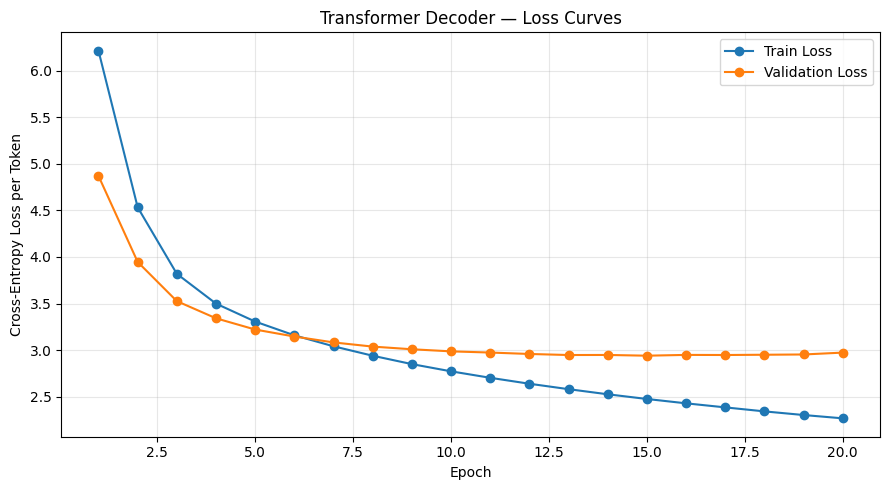

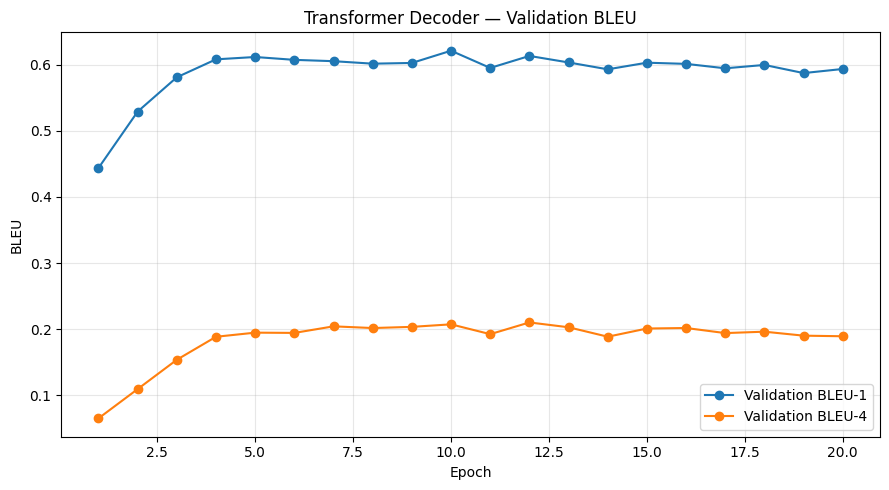

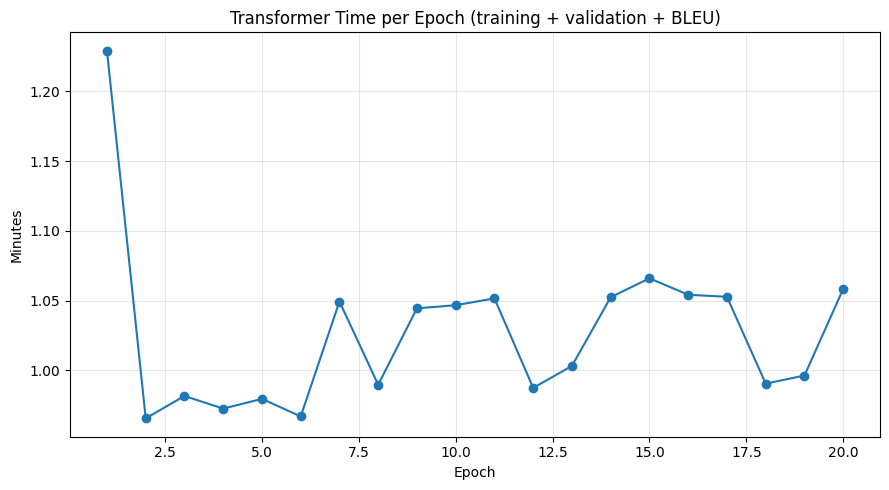

In [19]:
history_df = pd.DataFrame(history)
display(history_df)

HISTORY_PATH = os.path.join(CFG.OUTPUT_DIR, "training_history.csv")
history_df.to_csv(HISTORY_PATH, index=False)

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss per Token")
plt.title("Transformer Decoder — Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
LOSS_CURVE = os.path.join(CFG.OUTPUT_DIR, "loss_curve.png")
plt.savefig(LOSS_CURVE, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["val_bleu1"], marker="o", label="Validation BLEU-1")
plt.plot(history_df["epoch"], history_df["val_bleu4"], marker="o", label="Validation BLEU-4")
plt.xlabel("Epoch")
plt.ylabel("BLEU")
plt.title("Transformer Decoder — Validation BLEU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
BLEU_CURVE = os.path.join(CFG.OUTPUT_DIR, "validation_bleu_curve.png")
plt.savefig(BLEU_CURVE, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["epoch_time_sec"] / 60.0, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Minutes")
plt.title("Transformer Time per Epoch (training + validation + BLEU)")
plt.grid(alpha=0.3)
plt.tight_layout()
TIME_CURVE = os.path.join(CFG.OUTPUT_DIR, "epoch_time_curve.png")
plt.savefig(TIME_CURVE, dpi=160, bbox_inches="tight")
plt.show()

## 16. Convergence and overfitting summary

In [20]:
min_loss_idx = history_df["val_loss"].idxmin()
min_loss_epoch = int(history_df.loc[min_loss_idx, "epoch"])

# Read the checkpoint actually selected by the training loop.
selected_ckpt = torch.load(
    BEST_CKPT_PATH,
    map_location="cpu",
)

selected_best_epoch = int(selected_ckpt["epoch"]) + 1
selected_best_bleu4 = float(selected_ckpt["best_val_bleu4"])

print(
    f"Minimum validation loss = "
    f"{history_df.loc[min_loss_idx, 'val_loss']:.4f} "
    f"at epoch {min_loss_epoch}"
)

print(
    f"Selected best validation BLEU-4 = "
    f"{selected_best_bleu4:.6f} "
    f"at epoch {selected_best_epoch}"
)

print(
    f"Average epoch time = "
    f"{history_df['epoch_time_sec'].mean()/60:.2f} min"
)

if min_loss_epoch < history_df["epoch"].max():
    later = history_df[
        history_df["epoch"] > min_loss_epoch
    ]

    if (
        len(later) > 0
        and later["train_loss"].iloc[-1]
        < history_df.loc[min_loss_idx, "train_loss"]
        and later["val_loss"].iloc[-1]
        > history_df.loc[min_loss_idx, "val_loss"]
    ):
        print(
            "Later epochs show an overfitting pattern: "
            "train loss decreases while val loss rises."
        )


Minimum validation loss = 2.9413 at epoch 15
Selected best validation BLEU-4 = 0.210257 at epoch 12
Average epoch time = 1.03 min
Later epochs show an overfitting pattern: train loss decreases while val loss rises.


## 17. Final Test BLEU-1 and BLEU-4

In [21]:
best_checkpoint = load_best_model(BEST_CKPT_PATH)
test_result = evaluate_bleu(test_references)

test_bleu1 = test_result["bleu1"]
test_bleu4 = test_result["bleu4"]
end_rate = float(np.mean(test_result["finished"]))

print("Best checkpoint epoch:", int(best_checkpoint["epoch"]) + 1)
print(f"Test BLEU-1: {test_bleu1:.4f}")
print(f"Test BLEU-4: {test_bleu4:.4f}")
print(f"<end> generated: {100*end_rate:.2f}%")
print(f"No <end> before limit: {100*(1-end_rate):.2f}%")

test_metrics = {
    "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
    "dataset": manifest["dataset"],
    "vocab_size": VOCAB_SIZE,
    "max_len": MAX_LEN,
    "model": "Frozen ResNet50 + Transformer Decoder",
    "selection_metric": "full_validation_bleu4",
    "best_checkpoint_epoch": int(best_checkpoint["epoch"]) + 1,
    "best_validation_bleu4": float(best_checkpoint["best_val_bleu4"]),
    "test_bleu1": float(test_bleu1),
    "test_bleu4": float(test_bleu4),
    "test_end_token_rate": float(end_rate),
    "test_no_end_rate": float(1.0 - end_rate),
    "num_test_images": len(test_result["image_names"]),
    "average_epoch_time_sec": float(history_df["epoch_time_sec"].mean()),
}

TEST_METRICS_PATH = os.path.join(CFG.OUTPUT_DIR, "test_metrics.json")
with open(TEST_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

BLEU decoding:   0%|          | 0/13 [00:00<?, ?it/s]

Best checkpoint epoch: 12
Test BLEU-1: 0.5963
Test BLEU-4: 0.1942
<end> generated: 99.88%
No <end> before limit: 0.12%


## Secondary Beam-3 evaluation

The official comparison with LSTM remains **Greedy**, because Part 1 uses Greedy.

Beam-3 is additionally evaluated on the same test images to answer a separate
question: *how much caption quality can be recovered by a stronger decoding
algorithm without changing the trained model?*


In [22]:

@torch.no_grad()
def beam_search_one(
    spatial_feature,
    beam_size=3,
    length_penalty=0.7,
    max_new_tokens=GEN_MAX_NEW_TOKENS,
):
    model.eval()

    spatial_feature = spatial_feature.to(
        DEVICE
    )

    beams = [
        (
            [START_ID],
            0.0,
            False,
        )
    ]

    def rank_score(
        item,
    ):
        tokens, log_score, _ = item

        output_len = max(
            1,
            len(tokens) - 1,
        )

        return (
            log_score
            / (
                output_len
                ** length_penalty
            )
        )

    for _ in range(
        max_new_tokens
    ):
        candidates = []

        for (
            prefix_ids,
            log_score,
            finished,
        ) in beams:
            if finished:
                candidates.append(
                    (
                        prefix_ids,
                        log_score,
                        True,
                    )
                )

                continue

            prefix = torch.tensor(
                prefix_ids,
                dtype=torch.long,
                device=DEVICE,
            ).unsqueeze(
                0
            )

            logits = model(
                spatial_feature,
                prefix,
            )[
                0,
                -1,
            ].clone()

            logits[
                PAD_ID
            ] = -torch.inf

            logits[
                START_ID
            ] = -torch.inf

            log_probs = torch.log_softmax(
                logits,
                dim=-1,
            )

            values, indices = torch.topk(
                log_probs,
                k=beam_size,
            )

            for value, token_id in zip(
                values.tolist(),
                indices.tolist(),
            ):
                token_id = int(
                    token_id
                )

                candidates.append(
                    (
                        prefix_ids
                        + [
                            token_id
                        ],
                        log_score
                        + float(
                            value
                        ),
                        token_id
                        == END_ID,
                    )
                )

        beams = sorted(
            candidates,
            key=rank_score,
            reverse=True,
        )[
            :beam_size
        ]

        if all(
            finished
            for _, _, finished
            in beams
        ):
            break

    best = max(
        beams,
        key=rank_score,
    )

    return (
        best[0][1:],
        best[2],
    )


if CFG.RUN_BEAM3_TEST:
    beam_hypotheses = []
    beam_image_names = []
    beam_finished = []

    with h5py.File(
        FEATURES_H5_PATH,
        "r",
    ) as h5:
        for image_name in tqdm(
            test_result[
                "image_names"
            ],
            desc="Beam-3 test decoding",
        ):
            feature_idx = image_to_feature_idx[
                image_name
            ]

            spatial = np.asarray(
                h5[
                    "features"
                ][
                    feature_idx
                ],
                dtype=np.float32,
            )

            spatial = torch.from_numpy(
                spatial
            ).unsqueeze(
                0
            )

            ids, ended = beam_search_one(
                spatial,
                beam_size=CFG.BEAM_SIZE,
                length_penalty=CFG.BEAM_LENGTH_PENALTY,
            )

            beam_hypotheses.append(
                ids_to_words(
                    ids
                )
            )

            beam_finished.append(
                bool(
                    ended
                )
            )

            beam_image_names.append(
                image_name
            )

    beam_refs = [
        test_references[
            image_name
        ]
        for image_name in beam_image_names
    ]

    smoothing = SmoothingFunction().method1

    BEAM3_BLEU1 = corpus_bleu(
        beam_refs,
        beam_hypotheses,
        weights=(
            1.0,
            0.0,
            0.0,
            0.0,
        ),
        smoothing_function=smoothing,
    )

    BEAM3_BLEU4 = corpus_bleu(
        beam_refs,
        beam_hypotheses,
        weights=(
            0.25,
            0.25,
            0.25,
            0.25,
        ),
        smoothing_function=smoothing,
    )

    BEAM3_NO_END_RATE = 1.0 - (
        np.mean(
            beam_finished
        )
    )

    print(
        f"Beam-3 Test BLEU-1 = {BEAM3_BLEU1:.4f}"
    )

    print(
        f"Beam-3 Test BLEU-4 = {BEAM3_BLEU4:.4f}"
    )

    print(
        f"Beam-3 No-END rate = {100 * BEAM3_NO_END_RATE:.2f}%"
    )

    beam_rows = []

    for image_name, words in zip(
        beam_image_names,
        beam_hypotheses,
    ):
        beam_rows.append(
            {
                "image": image_name,
                "beam3_caption": " ".join(
                    words
                ),
            }
        )

    beam_df = pd.DataFrame(
        beam_rows
    )

    BEAM3_PATH = os.path.join(
        CFG.OUTPUT_DIR,
        "beam3_test_captions.csv",
    )

    beam_df.to_csv(
        BEAM3_PATH,
        index=False,
    )

else:
    BEAM3_BLEU1 = None
    BEAM3_BLEU4 = None
    BEAM3_NO_END_RATE = None
    BEAM3_PATH = None


Beam-3 test decoding:   0%|          | 0/810 [00:00<?, ?it/s]

Beam-3 Test BLEU-1 = 0.6099
Beam-3 Test BLEU-4 = 0.1985
Beam-3 No-END rate = 0.00%


## 18. Locate original Flickr8k images for qualitative examples and Attention Maps

In [23]:

def directory_matches_raw_flickr8k(
    path,
    expected_names,
):
    if path is None or not os.path.isdir(
        path
    ):
        return False

    targets = set(
        expected_names[
            : min(
                200,
                len(
                    expected_names
                ),
            )
        ]
    )

    try:
        files = set(
            f
            for f in os.listdir(
                path
            )
            if f.lower().endswith(
                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                )
            )
        )
    except Exception:
        return False

    return (
        len(files) >= 7000
        and len(
            targets
            & files
        )
        >= min(
            150,
            len(targets),
        )
    )


def locate_raw_images_dir(
    expected_names,
):
    if CFG.RAW_IMAGES_DIR is not None:
        assert directory_matches_raw_flickr8k(
            CFG.RAW_IMAGES_DIR,
            expected_names,
        ), (
            "CFG.RAW_IMAGES_DIR is not the expected Flickr8k image directory."
        )

        return (
            CFG.RAW_IMAGES_DIR
        )

    manifest_source = manifest.get(
        "source_images_dir"
    )

    if directory_matches_raw_flickr8k(
        manifest_source,
        expected_names,
    ):
        return manifest_source

    targets = set(
        expected_names[
            : min(
                200,
                len(
                    expected_names
                ),
            )
        ]
    )

    candidates = []

    for root in [
        "/kaggle/input",
    ]:
        if not os.path.exists(
            root
        ):
            continue

        for (
            dirpath,
            _,
            files,
        ) in os.walk(
            root
        ):
            image_files = [
                f
                for f in files
                if f.lower().endswith(
                    (
                        ".jpg",
                        ".jpeg",
                        ".png",
                    )
                )
            ]

            if len(
                image_files
            ) < 7000:
                continue

            matches = len(
                targets
                & set(
                    image_files
                )
            )

            candidates.append(
                (
                    matches,
                    len(
                        image_files
                    ),
                    dirpath,
                )
            )

    if not candidates:
        return None

    candidates.sort(
        reverse=True
    )

    matches, _, best_dir = (
        candidates[0]
    )

    if matches < min(
        150,
        len(
            targets
        ),
    ):
        return None

    return best_dir


def find_image_path(
    image_name,
    root,
):
    if root is None:
        return None

    direct = os.path.join(
        root,
        image_name,
    )

    if os.path.exists(
        direct
    ):
        return direct

    matches = list(
        Path(root).rglob(
            image_name
        )
    )

    return (
        str(
            matches[0]
        )
        if matches
        else None
    )


RAW_IMAGES_DIR = (
    locate_raw_images_dir(
        test_result[
            "image_names"
        ]
    )
)

print(
    "Raw Flickr8k images:",
    (
        RAW_IMAGES_DIR
        if RAW_IMAGES_DIR
        else (
            "not found — attach the same raw Flickr8k dataset "
            "used by Notebook 01 to produce qualitative and attention figures"
        )
    ),
)


Raw Flickr8k images: /kaggle/input/datasets/adityajn105/flickr8k/Images


## 19. Test examples: Image + Ground Truth + Transformer Caption

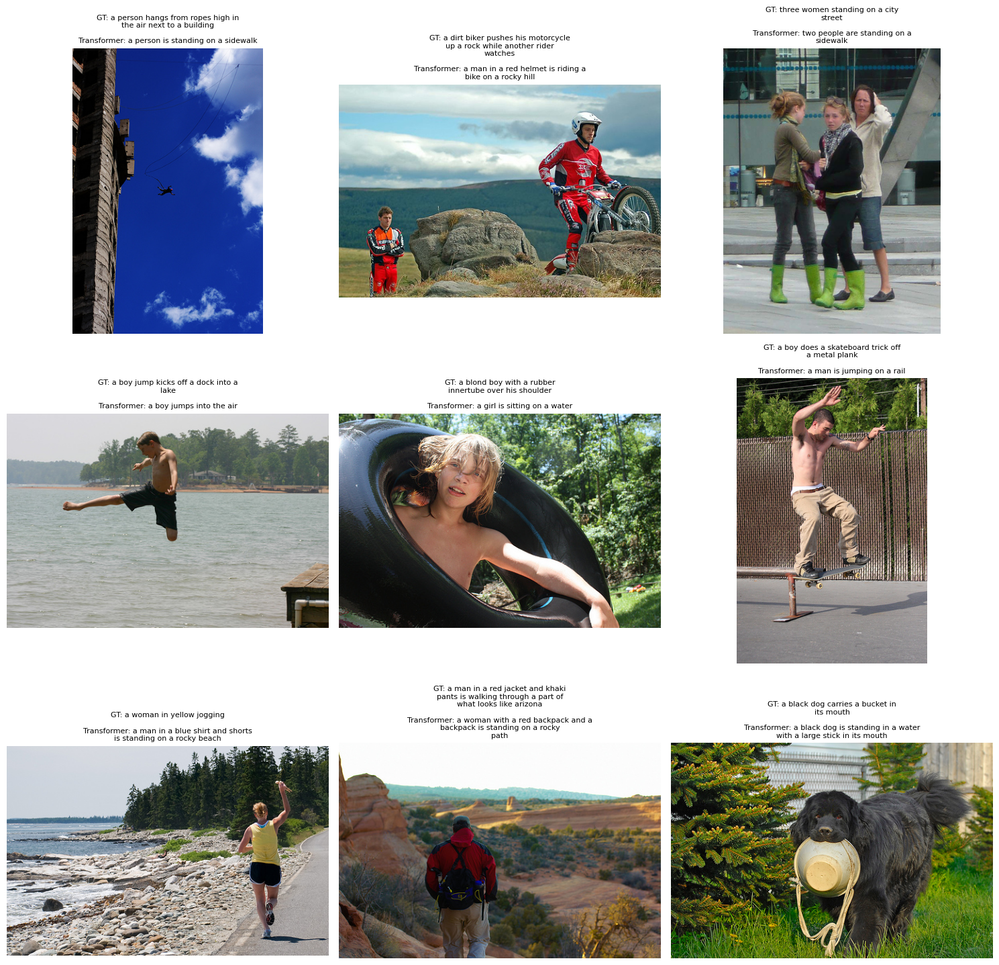

In [24]:
TRANSFORMER_SAMPLES = os.path.join(CFG.OUTPUT_DIR, "transformer_test_examples.png")

if RAW_IMAGES_DIR is not None:
    rng = random.Random(CFG.SEED)
    indices = rng.sample(
        range(len(test_result["image_names"])),
        min(9, len(test_result["image_names"])),
    )

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for ax, i in zip(axes.flat, indices):
        name = test_result["image_names"][i]
        gt = " ".join(test_result["references"][i][0])
        gen = " ".join(test_result["hypotheses"][i])
        path = find_image_path(name, RAW_IMAGES_DIR)

        if path:
            with Image.open(path) as image:
                ax.imshow(image.convert("RGB"))

        ax.axis("off")
        ax.set_title(
            "GT: " + textwrap.fill(gt, 34)
            + "\n\nTransformer: " + textwrap.fill(gen or "(empty)", 34),
            fontsize=8,
        )

    plt.tight_layout()
    plt.savefig(TRANSFORMER_SAMPLES, dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Raw images unavailable; qualitative figure skipped.")

## 20. Error, repetition, length, and no-END analysis

In [25]:
def repetition_ratio(words):
    if len(words) <= 1:
        return 0.0
    return 1.0 - len(set(words)) / len(words)


def per_image_bleu1(hyp, refs):
    return float(sentence_bleu(
        refs,
        hyp,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=SmoothingFunction().method1,
    ))


rows = []
for name, hyp, refs, finished in zip(
    test_result["image_names"],
    test_result["hypotheses"],
    test_result["references"],
    test_result["finished"],
):
    rows.append({
        "image": name,
        "generated": " ".join(hyp),
        "ground_truth_1": " ".join(refs[0]),
        "generated_length": len(hyp),
        "mean_reference_length": float(np.mean([len(r) for r in refs])),
        "repetition_ratio": repetition_ratio(hyp),
        "bleu1": per_image_bleu1(hyp, refs),
        "generated_end_token": bool(finished),
    })

analysis_df = pd.DataFrame(rows)
median_len = analysis_df["mean_reference_length"].median()
analysis_df["caption_length_complexity_proxy"] = np.where(
    analysis_df["mean_reference_length"] <= median_len,
    "short-reference proxy",
    "long-reference proxy",
)

print("Repetition > 0.30:", f"{100*(analysis_df['repetition_ratio'] > 0.30).mean():.2f}%")
print("No END:", f"{100*(~analysis_df['generated_end_token']).mean():.2f}%")
display(analysis_df.groupby("caption_length_complexity_proxy")["bleu1"].agg(["mean", "median", "count"]))

worst_examples = analysis_df.nsmallest(8, "bleu1")
best_examples = analysis_df.nlargest(8, "bleu1")
repetition_examples = analysis_df.nlargest(8, "repetition_ratio")

display(worst_examples[["image", "ground_truth_1", "generated", "bleu1"]])
display(repetition_examples[["image", "ground_truth_1", "generated", "repetition_ratio"]])

ANALYSIS_PATH = os.path.join(CFG.OUTPUT_DIR, "error_analysis.csv")
analysis_df.to_csv(ANALYSIS_PATH, index=False)
worst_examples.to_csv(os.path.join(CFG.OUTPUT_DIR, "worst_examples.csv"), index=False)
best_examples.to_csv(os.path.join(CFG.OUTPUT_DIR, "best_examples.csv"), index=False)
repetition_examples.to_csv(os.path.join(CFG.OUTPUT_DIR, "repetition_examples.csv"), index=False)

Repetition > 0.30: 18.02%
No END: 0.12%


,mean,median,count
caption_length_complexity_proxy,,,
long-reference proxy,0.593266,0.613363,385
short-reference proxy,0.580143,0.583333,425


,image,ground_truth_1,generated,bleu1
543,3420469425_2980b4cd30.jpg,a couple is holding their baby at a ceremony w...,three people are sitting in front of a table,0.088971
179,2460126267_0deea8b645.jpg,a boy standing on a football field with a colo...,two boys are playing soccer,0.089866
747,498492764_fe276e505a.jpg,a man in a gray suit locking up a bicycle,two men are sitting on a bench,0.107354
191,2488795251_c108c77b13.jpg,the girls smile at the camera,a young girl with a white dress and a white sh...,0.111111
595,3503624011_733d745d5a.jpg,a girl with a star painted on her face smiles,two young women pose for a large yellow and ye...,0.111111
113,2190227737_6e0bde2623.jpg,a girl holds something while three dogs beg,two dogs play together,0.118092
315,2882743431_c3e6cd1b5c.jpg,a black dog bites a white dog on the grass,two dogs are playing with a toy,0.123840
418,3159447439_c1496cbaea.jpg,two brown dogs are running through the green g...,a dog is running on a grassy path,0.125000


,image,ground_truth_1,generated,repetition_ratio
81,2057305043_952b8dc82c.jpg,a paraglider soars near a cliff and over a bod...,a person is jumping over a large large large l...,0.666667
156,2384728877_48c85d58af.jpg,a girl dressed in a red polka dot dress holds ...,a woman in a white shirt and a woman in a whit...,0.666667
362,3006095077_1992b677f8.jpg,a couple of men in hats posing for a picture b...,a man with a black shirt and a black shirt and...,0.666667
540,3416013671_98b5c75046.jpg,a grey bearded scottish gentleman in red plaid...,a man and a man wearing a black hat and a blac...,0.666667
712,410453140_5401bf659a.jpg,a man is standing in front of glass doors with...,a woman and a woman playing a pink pink and pi...,0.666667
676,3691670743_0ed111bcf3.jpg,a boy is jumping on skateboard in the middle o...,a small small small small small small small sm...,0.642857
154,2384353160_f395e9a54b.jpg,a man in a black fedora smiles at the camera,a man wearing a black hat and a black hat is w...,0.611111
240,2696060728_3043cfc38c.jpg,a girl stands on a surfboard which a man is st...,a woman in a red jacket is in a red jacket and...,0.611111


## 21. Failure-case figure for manual wrong-object / wrong-relation analysis

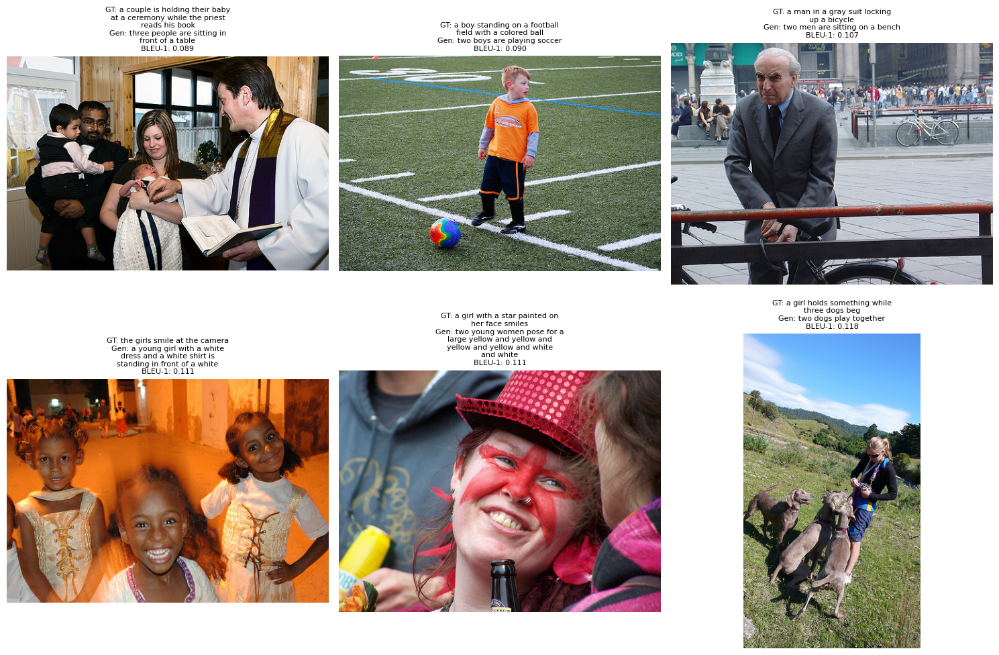

Inspect these cases manually for wrong objects, actions, and relationships.


In [26]:
FAILURE_FIGURE = os.path.join(CFG.OUTPUT_DIR, "transformer_failure_cases.png")

if RAW_IMAGES_DIR is not None:
    n = min(6, len(worst_examples))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for ax, row in zip(axes.flat, worst_examples.head(n).itertuples(index=False)):
        path = find_image_path(row.image, RAW_IMAGES_DIR)
        if path:
            with Image.open(path) as image:
                ax.imshow(image.convert("RGB"))

        ax.axis("off")
        ax.set_title(
            "GT: " + textwrap.fill(row.ground_truth_1, 30)
            + "\nGen: " + textwrap.fill(row.generated, 30)
            + f"\nBLEU-1: {row.bleu1:.3f}",
            fontsize=8,
        )

    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FAILURE_FIGURE, dpi=160, bbox_inches="tight")
    plt.show()

    print("Inspect these cases manually for wrong objects, actions, and relationships.")

# 22. LSTM Baseline vs Transformer comparison

This comparison uses the actual artifacts produced by the final Part-1 notebook when they are available.

In [27]:
baseline_metrics = None
baseline_history = None
baseline_analysis = None

if BASELINE_DIR is not None:
    p = os.path.join(BASELINE_DIR, "test_metrics.json")
    if os.path.exists(p):
        with open(p, encoding="utf-8") as f:
            baseline_metrics = json.load(f)

    p = os.path.join(BASELINE_DIR, "training_history.csv")
    if os.path.exists(p):
        baseline_history = pd.read_csv(p)

    p = os.path.join(BASELINE_DIR, "error_analysis.csv")
    if os.path.exists(p):
        baseline_analysis = pd.read_csv(p)


comparison_rows = [
    {
        "Metric": "Test BLEU-1",
        "LSTM Baseline": baseline_metrics.get("test_bleu1") if baseline_metrics else np.nan,
        "Transformer": test_bleu1,
    },
    {
        "Metric": "Test BLEU-4",
        "LSTM Baseline": baseline_metrics.get("test_bleu4") if baseline_metrics else np.nan,
        "Transformer": test_bleu4,
    },
    {
        "Metric": "Best validation epoch",
        "LSTM Baseline": baseline_metrics.get("best_checkpoint_epoch") if baseline_metrics else np.nan,
        "Transformer": int(best_checkpoint["epoch"]) + 1,
    },
    {
        "Metric": "No-END rate",
        "LSTM Baseline": baseline_metrics.get("test_no_end_rate") if baseline_metrics else np.nan,
        "Transformer": 1.0 - end_rate,
    },
    {
        "Metric": "Mean repetition ratio",
        "LSTM Baseline": (
            float(baseline_analysis["repetition_ratio"].mean())
            if baseline_analysis is not None else np.nan
        ),
        "Transformer": float(analysis_df["repetition_ratio"].mean()),
    },
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

COMPARISON_CSV = os.path.join(CFG.OUTPUT_DIR, "lstm_vs_transformer_metrics.csv")
comparison_df.to_csv(COMPARISON_CSV, index=False)

if baseline_metrics:
    print(f"BLEU-1 delta: {test_bleu1 - float(baseline_metrics['test_bleu1']):+.4f}")
    print(f"BLEU-4 delta: {test_bleu4 - float(baseline_metrics['test_bleu4']):+.4f}")

,Metric,LSTM Baseline,Transformer
0,Test BLEU-1,0.597998,0.596276
1,Test BLEU-4,0.196934,0.194169
2,Best validation epoch,17.000000,12.000000
3,No-END rate,0.009877,0.001235
4,Mean repetition ratio,0.158401,0.176891


BLEU-1 delta: -0.0017
BLEU-4 delta: -0.0028


## 23. Convergence comparison curve

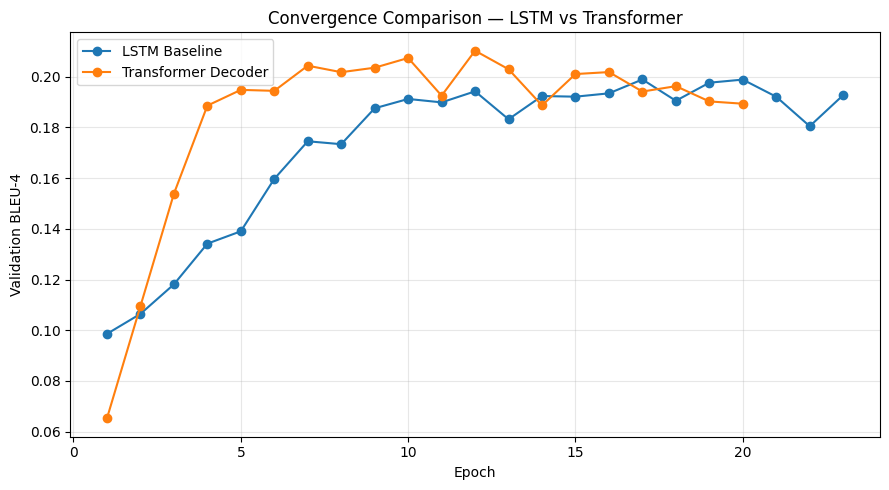

In [28]:
COMPARISON_CURVE = os.path.join(
    CFG.OUTPUT_DIR,
    "lstm_vs_transformer_validation_bleu4.png",
)

if baseline_history is not None and "val_bleu4" in baseline_history.columns:
    plt.figure(figsize=(9, 5))
    plt.plot(
        baseline_history["epoch"],
        baseline_history["val_bleu4"],
        marker="o",
        label="LSTM Baseline",
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_bleu4"],
        marker="o",
        label="Transformer Decoder",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Validation BLEU-4")
    plt.title("Convergence Comparison — LSTM vs Transformer")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(COMPARISON_CURVE, dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Baseline training history not found; comparison curve skipped.")

## 24. Paired LSTM vs Transformer caption examples

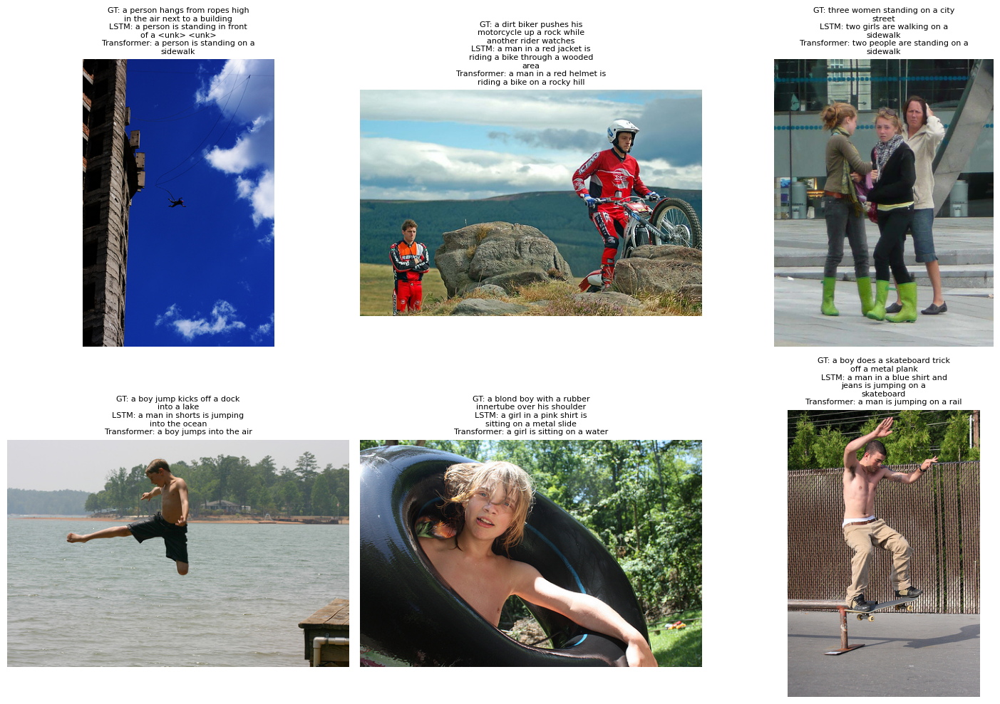

In [29]:
PAIRED_FIGURE = os.path.join(
    CFG.OUTPUT_DIR,
    "lstm_vs_transformer_caption_examples.png",
)

if RAW_IMAGES_DIR is not None and baseline_analysis is not None:
    transformer_map = dict(zip(
        test_result["image_names"],
        [" ".join(x) for x in test_result["hypotheses"]],
    ))
    baseline_map = (
        baseline_analysis.set_index("image")["generated"].astype(str).to_dict()
    )
    gt_map = test_df.groupby("image")["clean_caption"].first().to_dict()

    common = sorted(set(transformer_map) & set(baseline_map))
    rng = random.Random(CFG.SEED)
    selected = rng.sample(common, min(6, len(common)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for ax, name in zip(axes.flat, selected):
        path = find_image_path(name, RAW_IMAGES_DIR)
        if path:
            with Image.open(path) as image:
                ax.imshow(image.convert("RGB"))
        ax.axis("off")
        ax.set_title(
            "GT: " + textwrap.fill(gt_map[name], 30)
            + "\nLSTM: " + textwrap.fill(baseline_map[name], 30)
            + "\nTransformer: " + textwrap.fill(transformer_map[name], 30),
            fontsize=8,
        )

    for ax in axes.flat[len(selected):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(PAIRED_FIGURE, dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Paired examples require raw images and Part-1 error_analysis.csv.")

# 25. Cross-Attention analysis

The final decoder layer returns:

`(batch, heads, text_positions, 49 image regions)`

For each generated word, this notebook:

1. takes the Cross-Attention used to predict that word,
2. uses the final Transformer decoder layer,
3. averages the attention heads,
4. reshapes 49 weights to `7×7`,
5. upsamples the map to `224×224`,
6. overlays it on the exact center-cropped image used by ResNet50.

**Interpretation note:** Attention maps visualize attention behavior; they are not guaranteed causal explanations.

In [30]:
STOPWORDS = {
    "a", "an", "the", "is", "are", "was", "were",
    "in", "on", "at", "to", "of", "and", "or",
    "with", "for", "from", "by", "as",
    "his", "her", "their", "this", "that",
}


def important_indices(words, max_words):
    preferred = [
        i for i, word in enumerate(words)
        if word not in STOPWORDS and word != "<unk>" and len(word) > 2
    ]
    fallback = [i for i in range(len(words)) if i not in preferred]
    return (preferred + fallback)[:max_words]


@torch.no_grad()
def generate_one_with_attention(image_name):
    feature_idx = image_to_feature_idx[image_name]

    with h5py.File(FEATURES_H5_PATH, "r") as h5:
        spatial = np.asarray(
            h5["features"][feature_idx],
            dtype=np.float32,
        )

    spatial = torch.from_numpy(spatial).unsqueeze(0).to(DEVICE)

    generated, finished, attention_history = model.generate(
        spatial,
        start_id=START_ID,
        end_id=END_ID,
        pad_id=PAD_ID,
        max_new_tokens=GEN_MAX_NEW_TOKENS,
        return_attention=True,
    )

    ids = generated[0].cpu().tolist()
    words, maps = [], []

    for step, token_id in enumerate(ids):
        token_id = int(token_id)
        if token_id == END_ID:
            break
        if token_id in (PAD_ID, START_ID):
            continue

        words.append(idx2word[token_id])
        maps.append(
            attention_history[step][0].float().cpu().numpy()
        )

    return {
        "image": image_name,
        "words": words,
        "attention_maps": maps,
        "finished": bool(finished[0].item()),
    }


def resize_attention(attention_49, size=224):
    heat = torch.tensor(attention_49, dtype=torch.float32).reshape(1, 1, 7, 7)
    heat = F.interpolate(
        heat,
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()

    lo, hi = float(heat.min()), float(heat.max())
    if hi > lo:
        heat = (heat - lo) / (hi - lo)
    return heat

## 26. Generate report-ready Attention Maps

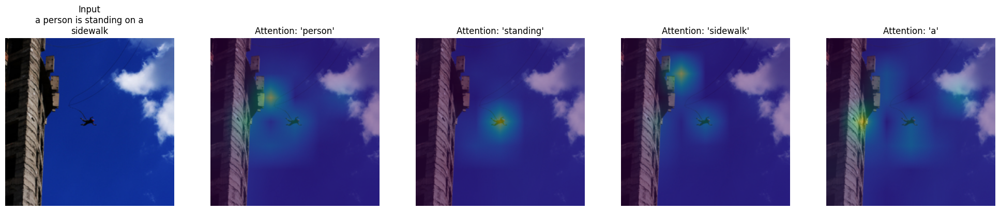

Saved: /kaggle/working/part2_transformer_research_tuned_v5/attention_maps/3632225464_612d7b4c0f_attention.png


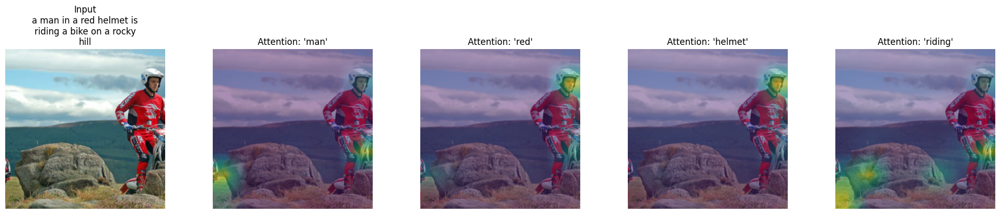

Saved: /kaggle/working/part2_transformer_research_tuned_v5/attention_maps/219070971_ae43410b9e_attention.png


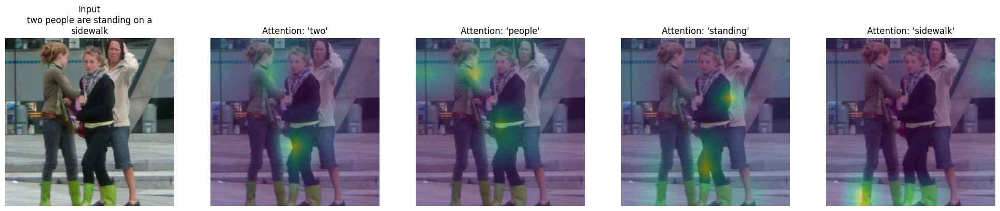

Saved: /kaggle/working/part2_transformer_research_tuned_v5/attention_maps/1332722096_1e3de8ae70_attention.png


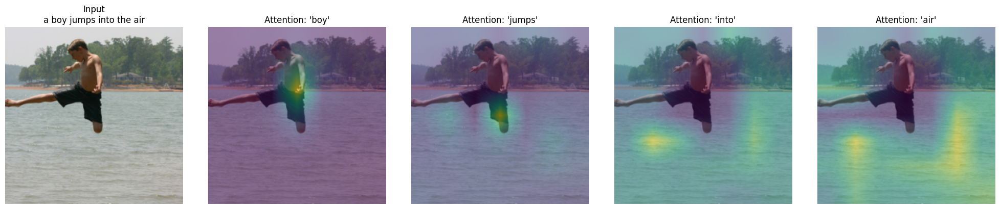

Saved: /kaggle/working/part2_transformer_research_tuned_v5/attention_maps/529101401_ab1f6b1206_attention.png


,image,generated_caption,word,word_position,attention_argmax_region,grid_row,grid_col
0,3632225464_612d7b4c0f.jpg,a person is standing on a sidewalk,person,1,16,2,2
1,3632225464_612d7b4c0f.jpg,a person is standing on a sidewalk,standing,3,24,3,3
2,3632225464_612d7b4c0f.jpg,a person is standing on a sidewalk,sidewalk,6,9,1,2
3,3632225464_612d7b4c0f.jpg,a person is standing on a sidewalk,a,0,22,3,1
4,219070971_ae43410b9e.jpg,a man in a red helmet is riding a bike on a ro...,man,1,35,5,0
5,219070971_ae43410b9e.jpg,a man in a red helmet is riding a bike on a ro...,red,4,13,1,6
6,219070971_ae43410b9e.jpg,a man in a red helmet is riding a bike on a ro...,helmet,5,13,1,6
7,219070971_ae43410b9e.jpg,a man in a red helmet is riding a bike on a ro...,riding,7,36,5,1
8,1332722096_1e3de8ae70.jpg,two people are standing on a sidewalk,two,0,31,4,3
9,1332722096_1e3de8ae70.jpg,two people are standing on a sidewalk,people,1,9,1,2


In [31]:
ATTENTION_DIR = os.path.join(CFG.OUTPUT_DIR, "attention_maps")
os.makedirs(ATTENTION_DIR, exist_ok=True)

# Spatial crop matching the ResNet50 pretrained transform.
attention_display_transform = T.Compose([
    T.Resize(232),
    T.CenterCrop(224),
])

attention_records = []

if RAW_IMAGES_DIR is not None:
    candidates = [
        name
        for name, hyp in zip(
            test_result["image_names"],
            test_result["hypotheses"],
        )
        if len(hyp) >= 4
    ]

    rng = random.Random(CFG.SEED)
    selected_images = rng.sample(
        candidates,
        min(CFG.N_ATTENTION_IMAGES, len(candidates)),
    )

    for image_name in selected_images:
        result = generate_one_with_attention(image_name)
        path = find_image_path(image_name, RAW_IMAGES_DIR)
        if path is None:
            continue

        with Image.open(path) as image:
            display_image = attention_display_transform(image.convert("RGB"))

        words = result["words"]
        maps = result["attention_maps"]
        chosen = important_indices(words, CFG.MAX_ATTENTION_WORDS_PER_IMAGE)

        if not chosen:
            continue

        fig, axes = plt.subplots(
            1,
            1 + len(chosen),
            figsize=(4 * (1 + len(chosen)), 4),
        )
        axes = np.atleast_1d(axes)

        axes[0].imshow(display_image)
        axes[0].axis("off")
        axes[0].set_title(
            "Input\n" + textwrap.fill(" ".join(words), 28)
        )

        for plot_idx, word_idx in enumerate(chosen, start=1):
            heat = resize_attention(maps[word_idx])

            axes[plot_idx].imshow(display_image)
            axes[plot_idx].imshow(heat, alpha=0.45)
            axes[plot_idx].axis("off")
            axes[plot_idx].set_title(f"Attention: '{words[word_idx]}'")

            max_region = int(np.argmax(maps[word_idx]))
            attention_records.append({
                "image": image_name,
                "generated_caption": " ".join(words),
                "word": words[word_idx],
                "word_position": int(word_idx),
                "attention_argmax_region": max_region,
                "grid_row": max_region // 7,
                "grid_col": max_region % 7,
            })

        plt.tight_layout()
        out = os.path.join(
            ATTENTION_DIR,
            Path(image_name).stem + "_attention.png",
        )
        plt.savefig(out, dpi=160, bbox_inches="tight")
        plt.show()
        print("Saved:", out)
else:
    print("Raw images not found; Attention overlay figures cannot be produced.")

attention_records_df = pd.DataFrame(attention_records)
ATTENTION_RECORDS = os.path.join(
    CFG.OUTPUT_DIR,
    "attention_map_records.csv",
)
attention_records_df.to_csv(ATTENTION_RECORDS, index=False)
display(attention_records_df)

## 27. Understanding the 49 image regions

The spatial tokens are interpreted as a 7×7 grid in row-major order:

```text
 0   1   2   3   4   5   6
 7   8   9  10  11  12  13
14  15  16  17  18  19  20
21  22  23  24  25  26  27
28  29  30  31  32  33  34
35  36  37  38  39  40  41
42  43  44  45  46  47  48
```

The complete heatmap is more informative than only the maximum cell because attention is distributed.

## 28. Hyperparameter table

In [32]:
hyperparameters = {
    "Learning Rate": CFG.LR,
    "Batch Size": CFG.BATCH_SIZE,
    "Epochs Trained": len(history_df),
    "Maximum Epochs": CFG.MAX_EPOCHS,
    "Optimizer": CFG.OPTIMIZER_NAME,
    "Weight Decay": CFG.WEIGHT_DECAY,
    "Gradient Clip Norm": CFG.GRAD_CLIP,
    "Encoder": "SAME Part-1 frozen ResNet50 ImageNet-V2",
    "GloVe Initialization": bool(GLOVE_FILE is not None),
    "GloVe Coverage": round(GLOVE_COVERAGE, 4),
    "Word Embedding Dimension": CFG.EMBEDDING_DIM,
    "Image Features": f"{NUM_IMAGE_TOKENS} × {FEAT_DIM} spatial ResNet tokens",
    "Decoder": "Standard Transformer Decoder (replaces LSTM only)",
    "d_model": CFG.D_MODEL,
    "Heads": CFG.NUM_HEADS,
    "Decoder Layers": CFG.NUM_LAYERS,
    "Feed-Forward Dimension": CFG.FF_DIM,
    "Dropout": CFG.DROPOUT,
    "Positional Encoding": "Learned positional embeddings for caption tokens",
    "Word Entry Mapping": "Embedding -> Linear -> LeakyReLU -> Residual MLP",
    "Transformer Norm": "Post-LayerNorm",
    "Attention Dropout": CFG.ATTENTION_DROPOUT,
    "FF Dropout": CFG.FF_DROPOUT,
    "Warmup Fraction": CFG.WARMUP_FRACTION,
    "Self-Attention": "Masked Multi-Head Self-Attention",
    "Cross-Attention": "Caption queries → 49 image tokens",
    "Vocabulary Size": VOCAB_SIZE,
    "Max Caption Length": MAX_LEN,
    "Generation": "Greedy autoregressive decoding",
    "Best Model Selection": "Full Validation BLEU-4",
    "Test BLEU-1": round(test_bleu1, 4),
    "Test BLEU-4": round(test_bleu4, 4),
    "Beam-3 Test BLEU-1 (secondary)": None if BEAM3_BLEU1 is None else round(BEAM3_BLEU1, 4),
    "Beam-3 Test BLEU-4 (secondary)": None if BEAM3_BLEU4 is None else round(BEAM3_BLEU4, 4),
}

hyper_df = pd.DataFrame(
    list(hyperparameters.items()),
    columns=["Hyperparameter", "Value"],
)
display(hyper_df)

HYPERPARAM_PATH = os.path.join(
    CFG.OUTPUT_DIR,
    "hyperparameters_table.csv",
)
hyper_df.to_csv(HYPERPARAM_PATH, index=False)

,Hyperparameter,Value
0,Learning Rate,0.0001
1,Batch Size,64
2,Epochs Trained,20
3,Maximum Epochs,35
4,Optimizer,AdamW
5,Weight Decay,0.00001
6,Gradient Clip Norm,1.0
7,Encoder,SAME Part-1 frozen ResNet50 ImageNet-V2
8,GloVe Initialization,False
9,GloVe Coverage,0.0


# 29. Save the final compact Transformer model

This bundle stores the **best learned Transformer decoder**, its vocabulary, architecture, generation settings, image preprocessing metadata, and test metrics.

In [33]:
best_checkpoint = load_best_model(BEST_CKPT_PATH)

FINAL_MODEL_PATH = os.path.join(CFG.OUTPUT_DIR, CFG.FINAL_MODEL)

final_bundle = {
    "format_version": 5,
    "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
    "encoder_unchanged_from_part1": True,
    "model_name": "Same Part-1 ResNet50 + Research-Tuned Transformer Decoder",
    "selection_metric": "full_validation_bleu4",
    "best_epoch": int(best_checkpoint["epoch"]) + 1,
    "best_validation_bleu4": float(best_checkpoint["best_val_bleu4"]),
    "test_metrics": test_metrics,

    "transformer_state_dict": {
        k: v.detach().cpu()
        for k, v in model.state_dict().items()
    },

    "model_config": model_config(),

    "generation_config": {
        "start_id": START_ID,
        "end_id": END_ID,
        "pad_id": PAD_ID,
        "unk_id": UNK_ID,
        "max_new_tokens": GEN_MAX_NEW_TOKENS,
        "strategy": "greedy",
    },

    "encoder_config": {
        "name": "resnet50",
        "weights": "IMAGENET1K_V2",
        "frozen": True,
        "feature_mode": "spatial",
        "num_spatial_tokens": NUM_IMAGE_TOKENS,
        "feature_dim": FEAT_DIM,
    },

    "decoder_training": {
        "glove_initialized": bool(GLOVE_FILE is not None),
        "glove_coverage": float(GLOVE_COVERAGE),
        "warmup_fraction": float(CFG.WARMUP_FRACTION),
        "post_layer_norm": True,
        "learned_text_position": True,
        "primary_decoding": "greedy",
        "secondary_decoding": "beam3" if CFG.RUN_BEAM3_TEST else None,
    },

    "image_transform": manifest["image_transform"],
    "vocabulary": {
        "word2idx": word2idx,
        "idx2word": idx2word,
    },
}

torch.save(final_bundle, FINAL_MODEL_PATH)
print("Saved:", FINAL_MODEL_PATH)
print(f"Size: {os.path.getsize(FINAL_MODEL_PATH)/1e6:.2f} MB")

Saved: /kaggle/working/part2_transformer_research_tuned_v5/transformer_decoder_final_model.pt
Size: 20.06 MB


# 30. Self-contained end-to-end presentation model

For presentation use, this optional bundle stores both:

- pretrained ResNet50 encoder weights,
- the best trained Transformer decoder weights.

Therefore it can run directly on a raw image:

```text
Raw image → ResNet50 → 49 spatial features → Transformer → Caption
```

The pretrained ResNet50 weights only need to be accessible once while this packaging cell runs.

In [34]:

class EndToEndTransformerCaptioner(nn.Module):
    def __init__(
        self,
        model_cfg,
    ):
        super().__init__()

        backbone = tvm.resnet50(
            weights=None
        )

        self.encoder = nn.Sequential(
            *list(
                backbone.children()
            )[:-2]
        )

        self.decoder = TransformerCaptionModel(
            vocab_size=model_cfg["vocab_size"],
            feat_dim=2048,
            embedding_dim=model_cfg["embedding_dim"],
            d_model=model_cfg["d_model"],
            num_heads=model_cfg["num_heads"],
            num_layers=model_cfg["num_layers"],
            ff_dim=model_cfg["ff_dim"],
            dropout=model_cfg["dropout"],
            attention_dropout=model_cfg["attention_dropout"],
            ff_dropout=model_cfg["ff_dropout"],
            max_len=model_cfg["max_len"],
            pad_id=model_cfg["pad_id"],
            pretrained_embedding_matrix=None,
            finetune_pretrained=True,
        )

    def encode_image(
        self,
        images,
    ):
        x = self.encoder(
            images
        )

        return (
            x.flatten(
                2
            )
            .transpose(
                1,
                2,
            )
        )

    def forward(
        self,
        images,
        input_tokens,
    ):
        return self.decoder(
            self.encode_image(
                images
            ),
            input_tokens,
        )

    @torch.no_grad()
    def generate(
        self,
        images,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
        return_attention=False,
    ):
        return self.decoder.generate(
            self.encode_image(
                images
            ),
            start_id=start_id,
            end_id=end_id,
            pad_id=pad_id,
            max_new_tokens=max_new_tokens,
            return_attention=return_attention,
        )


FULL_MODEL_PATH = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.FULL_PRESENTATION_MODEL,
)

full_bundle_created = False

try:
    print(
        "Loading exact ResNet50 ImageNet-V2 pretrained weights..."
    )

    pretrained_resnet = tvm.resnet50(
        weights=tvm.ResNet50_Weights.IMAGENET1K_V2
    )

    pretrained_encoder = nn.Sequential(
        *list(
            pretrained_resnet.children()
        )[:-2]
    )

    full_model = EndToEndTransformerCaptioner(
        model_config()
    )

    full_model.encoder.load_state_dict(
        pretrained_encoder.state_dict()
    )

    full_model.decoder.load_state_dict(
        model.state_dict()
    )

    full_model.eval()

    full_bundle = {
        "format_version": 5,
        "model_name": (
            "End-to-End SAME ResNet50 + Research-Tuned Transformer"
        ),

        "state_dict": {
            key: value.detach().cpu()
            for key, value
            in full_model.state_dict().items()
        },

        "model_config": model_config(),

        "generation_config": {
            "start_id": START_ID,
            "end_id": END_ID,
            "pad_id": PAD_ID,
            "unk_id": UNK_ID,
            "max_new_tokens": GEN_MAX_NEW_TOKENS,
            "strategy": "greedy",
        },

        "image_transform": {
            "resize_size": 232,
            "crop_size": 224,
            "mean": [
                0.485,
                0.456,
                0.406,
            ],
            "std": [
                0.229,
                0.224,
                0.225,
            ],
        },

        "vocabulary": {
            "word2idx": word2idx,
            "idx2word": idx2word,
        },

        "test_metrics": test_metrics,
        "beam3_test_bleu1": BEAM3_BLEU1,
        "beam3_test_bleu4": BEAM3_BLEU4,
    }

    torch.save(
        full_bundle,
        FULL_MODEL_PATH,
    )

    full_bundle_created = True

    print(
        "Full presentation model saved:"
    )

    print(
        FULL_MODEL_PATH
    )

    print(
        f"Size: "
        f"{os.path.getsize(FULL_MODEL_PATH)/1e6:.2f} MB"
    )

    del (
        pretrained_resnet,
        pretrained_encoder,
        full_model,
    )

    gc.collect()

except Exception as exc:
    print(
        "Could not build the self-contained bundle."
    )

    print(
        "Reason:",
        repr(
            exc
        ),
    )

    print(
        "The compact trained model is still saved at:"
    )

    print(
        FINAL_MODEL_PATH
    )


Loading exact ResNet50 ImageNet-V2 pretrained weights...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


Full presentation model saved:
/kaggle/working/part2_transformer_research_tuned_v5/transformer_full_presentation_bundle.pt
Size: 114.41 MB


## 31. Create a standalone presentation inference script

Example:

```bash
python transformer_presentation_inference.py \
  --model transformer_full_presentation_bundle.pt \
  --image sample.jpg
```

In [35]:
# Local import so this cell is safe even when run independently.
import ast


presentation_script = r"""
import argparse
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as tvm
import torchvision.transforms as T


class LearnedTokenPositionEmbedding(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.token_embedding = nn.Embedding(
            cfg["vocab_size"],
            cfg["embedding_dim"],
            padding_idx=cfg["pad_id"],
        )

        self.word_projection = nn.Linear(
            cfg["embedding_dim"],
            cfg["d_model"],
        )

        self.word_residual = nn.Sequential(
            nn.Linear(cfg["d_model"], cfg["d_model"]),
            nn.LeakyReLU(0.1),
            nn.Linear(cfg["d_model"], cfg["d_model"]),
        )

        self.position_embedding = nn.Embedding(
            cfg["max_len"],
            cfg["d_model"],
        )

        self.dropout = nn.Dropout(
            cfg["dropout"]
        )

        self.activation = nn.LeakyReLU(
            0.1
        )

    def forward(self, token_ids):
        x = self.activation(
            self.word_projection(
                self.token_embedding(
                    token_ids
                )
            )
        )

        x = self.activation(
            x
            + self.word_residual(
                x
            )
        )

        positions = torch.arange(
            token_ids.size(1),
            device=token_ids.device,
        )

        return self.dropout(
            x
            + self.position_embedding(
                positions
            ).unsqueeze(0)
        )


class DecoderLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        d = cfg["d_model"]

        self.self_attn = nn.MultiheadAttention(
            d,
            cfg["num_heads"],
            dropout=cfg["attention_dropout"],
            batch_first=True,
        )

        self.cross_attn = nn.MultiheadAttention(
            d,
            cfg["num_heads"],
            dropout=cfg["attention_dropout"],
            batch_first=True,
        )

        self.ffn = nn.Sequential(
            nn.Linear(d, cfg["ff_dim"]),
            nn.ReLU(),
            nn.Dropout(cfg["ff_dropout"]),
            nn.Linear(cfg["ff_dim"], d),
        )

        self.norm1 = nn.LayerNorm(d)
        self.norm2 = nn.LayerNorm(d)
        self.norm3 = nn.LayerNorm(d)

        self.drop1 = nn.Dropout(cfg["dropout"])
        self.drop2 = nn.Dropout(cfg["dropout"])
        self.drop3 = nn.Dropout(cfg["dropout"])

    def forward(self, x, memory, causal, padding):
        out, _ = self.self_attn(
            x, x, x,
            attn_mask=causal,
            key_padding_mask=padding,
            need_weights=False,
        )

        x = self.norm1(
            x + self.drop1(out)
        )

        out, _ = self.cross_attn(
            x, memory, memory,
            need_weights=False,
        )

        x = self.norm2(
            x + self.drop2(out)
        )

        x = self.norm3(
            x + self.drop3(
                self.ffn(x)
            )
        )

        return x


class TransformerDecoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.pad_id = int(cfg["pad_id"])

        self.image_projection = nn.Linear(
            2048,
            cfg["d_model"],
        )

        self.image_activation = nn.LeakyReLU(
            0.1
        )

        self.text_embedding = LearnedTokenPositionEmbedding(
            cfg
        )

        self.layers = nn.ModuleList(
            [
                DecoderLayer(cfg)
                for _ in range(
                    cfg["num_layers"]
                )
            ]
        )

        self.output_dropout = nn.Dropout(
            cfg["dropout"]
        )

        self.output_projection = nn.Linear(
            cfg["d_model"],
            cfg["vocab_size"],
        )

    def forward(self, spatial, tokens):
        memory = self.image_activation(
            self.image_projection(
                spatial
            )
        )

        x = self.text_embedding(
            tokens
        )

        t = tokens.size(1)

        causal = torch.triu(
            torch.ones(
                t, t,
                dtype=torch.bool,
                device=tokens.device,
            ),
            diagonal=1,
        )

        padding = tokens.eq(
            self.pad_id
        )

        for layer in self.layers:
            x = layer(
                x,
                memory,
                causal,
                padding,
            )

        return self.output_projection(
            self.output_dropout(
                x
            )
        )

    @torch.no_grad()
    def generate(
        self,
        spatial,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
    ):
        b = spatial.size(0)

        prefix = torch.full(
            (b, 1),
            start_id,
            dtype=torch.long,
            device=spatial.device,
        )

        generated = torch.full(
            (b, max_new_tokens),
            pad_id,
            dtype=torch.long,
            device=spatial.device,
        )

        finished = torch.zeros(
            b,
            dtype=torch.bool,
            device=spatial.device,
        )

        for step in range(max_new_tokens):
            logits = self(
                spatial,
                prefix,
            )[:, -1, :].clone()

            logits[:, pad_id] = -torch.inf
            logits[:, start_id] = -torch.inf

            token = logits.argmax(dim=-1)

            token = torch.where(
                finished,
                torch.full_like(
                    token,
                    pad_id,
                ),
                token,
            )

            generated[:, step] = token

            finished = (
                finished
                | token.eq(end_id)
            )

            prefix_token = torch.where(
                finished,
                torch.full_like(
                    token,
                    end_id,
                ),
                token,
            )

            prefix = torch.cat(
                [
                    prefix,
                    prefix_token.unsqueeze(1),
                ],
                dim=1,
            )

            if finished.all():
                break

        return generated


class EndToEndCaptioner(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        resnet = tvm.resnet50(
            weights=None
        )

        self.encoder = nn.Sequential(
            *list(
                resnet.children()
            )[:-2]
        )

        self.decoder = TransformerDecoder(
            cfg
        )

    def encode(self, images):
        x = self.encoder(images)

        return (
            x.flatten(2)
            .transpose(1, 2)
        )


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--model",
        required=True,
    )

    parser.add_argument(
        "--image",
        required=True,
    )

    args = parser.parse_args()

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    bundle = torch.load(
        args.model,
        map_location=device,
    )

    cfg = bundle["model_config"]
    generation = bundle["generation_config"]

    model = EndToEndCaptioner(
        cfg
    ).to(device)

    model.load_state_dict(
        bundle["state_dict"]
    )

    model.eval()

    tf_cfg = bundle["image_transform"]

    transform = T.Compose(
        [
            T.Resize(tf_cfg["resize_size"]),
            T.CenterCrop(tf_cfg["crop_size"]),
            T.ToTensor(),
            T.Normalize(
                mean=tf_cfg["mean"],
                std=tf_cfg["std"],
            ),
        ]
    )

    with Image.open(args.image) as image:
        x = transform(
            image.convert("RGB")
        ).unsqueeze(0).to(device)

    with torch.no_grad():
        spatial = model.encode(x)

        ids = model.decoder.generate(
            spatial,
            start_id=generation["start_id"],
            end_id=generation["end_id"],
            pad_id=generation["pad_id"],
            max_new_tokens=generation["max_new_tokens"],
        )[0].cpu().tolist()

    idx2word = bundle["vocabulary"]["idx2word"]
    words = []

    for token_id in ids:
        if token_id == generation["end_id"]:
            break

        if token_id in (
            generation["pad_id"],
            generation["start_id"],
        ):
            continue

        words.append(
            idx2word[int(token_id)]
        )

    print(" ".join(words))


if __name__ == "__main__":
    main()
"""

PRESENTATION_SCRIPT_PATH = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.PRESENTATION_SCRIPT,
)

with open(
    PRESENTATION_SCRIPT_PATH,
    "w",
    encoding="utf-8",
) as f:
    f.write(
        presentation_script.strip()
        + "\n"
    )

ast.parse(
    presentation_script
)

print(
    "Saved standalone inference script:",
    PRESENTATION_SCRIPT_PATH,
)


Saved standalone inference script: /kaggle/working/part2_transformer_research_tuned_v5/transformer_presentation_inference.py


## 32. Optional end-to-end demo using the saved presentation bundle

Demo: 1007129816_e794419615.jpg
Caption: a man with a hat and a hat and a hat is wearing a hat


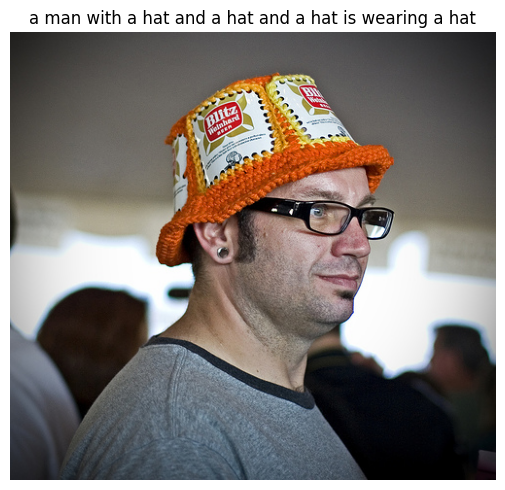

In [36]:
if full_bundle_created and RAW_IMAGES_DIR is not None:
    demo_name = test_result["image_names"][0]
    demo_path = find_image_path(demo_name, RAW_IMAGES_DIR)

    if demo_path:
        bundle = torch.load(FULL_MODEL_PATH, map_location=DEVICE)
        cfg = bundle["model_config"]

        demo_model = EndToEndTransformerCaptioner(
            cfg
        ).to(DEVICE)

        demo_model.load_state_dict(bundle["state_dict"])
        demo_model.eval()

        tf_cfg = bundle["image_transform"]
        transform = T.Compose([
            T.Resize(tf_cfg["resize_size"]),
            T.CenterCrop(tf_cfg["crop_size"]),
            T.ToTensor(),
            T.Normalize(mean=tf_cfg["mean"], std=tf_cfg["std"]),
        ])

        with Image.open(demo_path) as image:
            display_image = image.convert("RGB")
            x = transform(display_image).unsqueeze(0).to(DEVICE)

        generated, _, _ = demo_model.generate(
            x,
            start_id=START_ID,
            end_id=END_ID,
            pad_id=PAD_ID,
            max_new_tokens=GEN_MAX_NEW_TOKENS,
            return_attention=False,
        )

        caption = " ".join(ids_to_words(generated[0].cpu().tolist()))
        print("Demo:", demo_name)
        print("Caption:", caption)

        plt.figure(figsize=(7, 5))
        plt.imshow(display_image)
        plt.axis("off")
        plt.title(caption)
        plt.tight_layout()
        plt.show()

        del demo_model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
else:
    print("Demo skipped because full bundle or raw images are unavailable.")

## 33. Save Part-2 manifest and build the presentation ZIP package

In [37]:
part2_manifest = {
    "artifact_version": 2,
    "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
    "encoder_unchanged_from_part1": True,
    "research_tuned_decoder": {
        "optional_glove": True,
        "learned_text_position": True,
        "word_residual_mapping": True,
        "post_layer_norm": True,
        "linear_lr_warmup": True,
        "beam3_secondary_test": bool(CFG.RUN_BEAM3_TEST),
    },
    "preprocessing_directory_used": PREP_DIR,
    "matching_part1_baseline_directory": BASELINE_DIR,
    "project_section": "Part 2 - Transformer Decoder",
    "architecture": "Same Part-1 Frozen ResNet50 + Research-Tuned Transformer Decoder",
    "requirements": {
        "same_encoder_as_part1": True,
        "multi_head_self_attention": True,
        "cross_attention": True,
        "positional_encoding": True,
        "full_validation_bleu_model_selection": True,
        "attention_maps": True,
        "baseline_comparison_available": baseline_metrics is not None,
    },
    "hyperparameters": hyperparameters,
    "test_metrics": test_metrics,
    "files": {
        "best_checkpoint": CFG.BEST_CKPT,
        "last_checkpoint": CFG.LAST_CKPT,
        "compact_final_model": CFG.FINAL_MODEL,
        "full_presentation_model": (
            CFG.FULL_PRESENTATION_MODEL if full_bundle_created else None
        ),
        "presentation_script": CFG.PRESENTATION_SCRIPT,
        "attention_directory": "attention_maps",
        "attention_records": "attention_map_records.csv",
        "comparison_table": "lstm_vs_transformer_metrics.csv",
    },
}

PART2_MANIFEST_PATH = os.path.join(CFG.OUTPUT_DIR, "part2_manifest.json")
with open(PART2_MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(part2_manifest, f, indent=2, ensure_ascii=False)

PACKAGE_DIR = os.path.join(CFG.OUTPUT_DIR, "presentation_package")
os.makedirs(PACKAGE_DIR, exist_ok=True)

required_package_files = [
    FINAL_MODEL_PATH,
    PRESENTATION_SCRIPT_PATH,
    TEST_METRICS_PATH,
    HISTORY_PATH,
    HYPERPARAM_PATH,
    COMPARISON_CSV,
    LOSS_CURVE,
    BLEU_CURVE,
    TIME_CURVE,
    ANALYSIS_PATH,
    ATTENTION_RECORDS,
    PART2_MANIFEST_PATH,
]

optional_package_files = [
    TRANSFORMER_SAMPLES,
    FAILURE_FIGURE,
    COMPARISON_CURVE,
    PAIRED_FIGURE,
    FULL_MODEL_PATH if full_bundle_created else None,
]

for source in required_package_files + optional_package_files:
    if source and os.path.exists(source):
        shutil.copy2(
            source,
            os.path.join(PACKAGE_DIR, os.path.basename(source)),
        )

packaged_attention = os.path.join(PACKAGE_DIR, "attention_maps")
os.makedirs(packaged_attention, exist_ok=True)

for source in Path(ATTENTION_DIR).glob("*.png"):
    shutil.copy2(source, os.path.join(packaged_attention, source.name))

ZIP_PATH = shutil.make_archive(
    os.path.join(CFG.OUTPUT_DIR, "part2_transformer_presentation_package"),
    "zip",
    PACKAGE_DIR,
)

print("Manifest:", PART2_MANIFEST_PATH)
print("Presentation ZIP:", ZIP_PATH)

Manifest: /kaggle/working/part2_transformer_research_tuned_v5/part2_manifest.json
Presentation ZIP: /kaggle/working/part2_transformer_research_tuned_v5/part2_transformer_presentation_package.zip


## 34. Final deliverables produced by this notebook

```text
part2_transformer/
│
├── best_checkpoint.pt
├── last_checkpoint.pt
├── transformer_decoder_final_model.pt
├── transformer_full_presentation_bundle.pt   # if packaging succeeds
├── transformer_presentation_inference.py
│
├── training_history.csv
├── test_metrics.json
├── hyperparameters_table.csv
├── loss_curve.png
├── validation_bleu_curve.png
├── epoch_time_curve.png
│
├── lstm_vs_transformer_metrics.csv
├── lstm_vs_transformer_validation_bleu4.png
├── lstm_vs_transformer_caption_examples.png
│
├── error_analysis.csv
├── transformer_failure_cases.png
│
├── attention_map_records.csv
├── attention_maps/
│   └── *_attention.png
│
├── part2_manifest.json
└── part2_transformer_presentation_package.zip
```

In [38]:
files = sorted(
    p for p in Path(CFG.OUTPUT_DIR).rglob("*")
    if p.is_file()
)

for p in files:
    rel = p.relative_to(CFG.OUTPUT_DIR)
    print(f"{str(rel):60s} {p.stat().st_size/1e6:9.2f} MB")

print("\nFinal test results")
print(f"BLEU-1: {test_bleu1:.4f}")
print(f"BLEU-4: {test_bleu4:.4f}")
print(f"Best validation BLEU-4: {best_checkpoint['best_val_bleu4']:.4f}")
print(f"Best epoch: {int(best_checkpoint['epoch']) + 1}")

print("\nFor presentation:")
print("Compact model:", FINAL_MODEL_PATH)
if full_bundle_created:
    print("Raw-image model:", FULL_MODEL_PATH)
print("Inference script:", PRESENTATION_SCRIPT_PATH)
print("ZIP package:", ZIP_PATH)
print("Attention maps:", ATTENTION_DIR)

attention_map_records.csv                                         0.00 MB
attention_maps/1332722096_1e3de8ae70_attention.png                1.41 MB
attention_maps/219070971_ae43410b9e_attention.png                 1.35 MB
attention_maps/3632225464_612d7b4c0f_attention.png                1.04 MB
attention_maps/529101401_ab1f6b1206_attention.png                 1.38 MB
beam3_test_captions.csv                                           0.06 MB
best_checkpoint.pt                                               59.91 MB
best_examples.csv                                                 0.00 MB
epoch_time_curve.png                                              0.06 MB
error_analysis.csv                                                0.15 MB
hyperparameters_table.csv                                         0.00 MB
last_checkpoint.pt                                               59.91 MB
loss_curve.png                                                    0.07 MB
lstm_vs_transformer_caption_examples.p

# 35. Report discussion checklist

Use the actual outputs of this notebook in the report.

### Architecture
- Same frozen pretrained ResNet50 as Part 1.
- `7×7 = 49` spatial visual tokens.
- Image projection from 2048 to `d_model`.
- Masked Multi-Head Self-Attention.
- Multi-Head Cross-Attention.
- Sinusoidal Positional Encoding.
- Feed-forward blocks, residual connections, LayerNorm.

### Training
- Train and validation loss curves.
- Full validation BLEU-1 and BLEU-4.
- Best model selected by validation BLEU-4.
- Convergence epoch and overfitting behavior.

### LSTM vs Transformer
- Test BLEU-1 and BLEU-4.
- Best validation epoch.
- Caption examples from the same images.
- Word repetition.
- No-END generation rate.
- Qualitative behavior on simpler/complex examples.
- If Transformer does not outperform LSTM, report that result rather than hiding it and discuss dataset size, optimization, model capacity, and inductive bias.

### Attention analysis
For several important nouns/people/actions:
- show the center-cropped model input,
- show the generated caption,
- show the attention heatmap for the word,
- state whether the attention mass visually aligns with the relevant region.

Do **not** describe attention maps as guaranteed causal explanations; use them as a model-behavior analysis tool.

## 36. Short-reference vs long-reference comparison (complexity proxy)

The project asks for simple versus complex-image behavior. Flickr8k does not provide an official image-complexity label, so caption length must **not** be presented as ground-truth visual complexity.

This cell only provides a reproducible **reference-length proxy**. The final report should supplement it with manual visual examples.

# Part-2 Project Checklist

Before considering Part 2 complete, verify that the executed notebook produced:

- [ ] same ResNet50 encoder as Part 1
- [ ] masked Multi-Head Self-Attention
- [ ] Cross-Attention to 49 spatial ResNet features
- [ ] caption Positional Encoding
- [ ] training on the exact same split as Part 1
- [ ] Train / Validation Loss curve
- [ ] BLEU-1 and BLEU-4 on Test
- [ ] best checkpoint selected using Validation BLEU-4
- [ ] input image + Ground Truth + generated caption examples
- [ ] LSTM vs Transformer metric table
- [ ] convergence comparison
- [ ] repetition / incomplete-output comparison
- [ ] complex-image discussion support
- [ ] attention maps for important generated words

If the new Part-1 output is attached, all comparison cells should populate with
real LSTM values rather than `NaN`.


In [39]:
transformer_proxy = (
    analysis_df.groupby("caption_length_complexity_proxy")["bleu1"]
    .mean()
    .rename("Transformer BLEU-1")
)

if (
    baseline_analysis is not None
    and "caption_length_complexity_proxy" in baseline_analysis.columns
    and "bleu1" in baseline_analysis.columns
):
    baseline_proxy = (
        baseline_analysis.groupby("caption_length_complexity_proxy")["bleu1"]
        .mean()
        .rename("LSTM BLEU-1")
    )

    proxy_comparison = pd.concat(
        [baseline_proxy, transformer_proxy],
        axis=1,
    )

    display(proxy_comparison)

    proxy_path = os.path.join(
        CFG.OUTPUT_DIR,
        "lstm_vs_transformer_length_proxy.csv",
    )
    proxy_comparison.to_csv(proxy_path)
    print("Saved:", proxy_path)
else:
    print("Transformer reference-length proxy:")
    display(transformer_proxy.to_frame())
    print(
        "Attach the final Part-1 output to add the LSTM side of this comparison."
    )

,LSTM BLEU-1,Transformer BLEU-1
caption_length_complexity_proxy,,
long-reference proxy,0.592591,0.593266
short-reference proxy,0.573756,0.580143


Saved: /kaggle/working/part2_transformer_research_tuned_v5/lstm_vs_transformer_length_proxy.csv


## Interpretation rule for the report

Use **Greedy Test BLEU-1/BLEU-4** for the official LSTM-vs-Transformer table.

Beam-3 is a secondary decoding experiment and should be labeled separately.
If GloVe is used, state explicitly in the hyperparameter table that the
Transformer decoder embedding was pretrained/initialized from GloVe.
